In [1]:
import torch
import numpy as np
from training import train
from data_utils import make_dataset, load_dataset, fit_dset_to_m, make_grid_dataset
from controls import LQR
from tasks import stabilize_cartpole
from plotting import plot_trajectories, plot_experiment_new
from models import save_model, load_model
from experiments import save_experiment, load_experiment
import params
from IPython.display import HTML
from copy import deepcopy
import matplotlib.pyplot as plt
import seaborn as sns

######################
### DISPLAY CONFIG ###
######################
for name, values in vars(params).items():
    print(name, values)

torch.set_default_device("cuda")
#torch.set_default_device("cpu")

%load_ext autoreload
%autoreload 2

/home1/lutkus/.conda/envs/latent-space/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


__name__ params
__doc__ None
__package__ 
__loader__ <_frozen_importlib_external.SourceFileLoader object at 0x7fc084c0fb90>
__spec__ ModuleSpec(name='params', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7fc084c0fb90>, origin='/home1/lutkus/latent_space/cartpole_lyapunov/params.py')
__file__ /home1/lutkus/latent_space/cartpole_lyapunov/params.py
__cached__ /home1/lutkus/latent_space/cartpole_lyapunov/__pycache__/params.cpython-313.pyc
__builtins__ {'__name__': 'builtins', '__doc__': "Built-in functions, types, exceptions, and other objects.\n\nThis module provides direct access to all 'built-in'\nidentifiers of Python; for example, builtins.len is\nthe full name for the built-in function len().\n\nThis module is not normally accessed explicitly by most\napplications, but can be useful in modules that provide\nobjects with the same name as a built-in value, but in\nwhich the built-in of that name is also needed.", '__package__': '', '__loader__': <class '_frozen_impor

In [2]:
################################
### Load or Generate Dataset ###
################################

#data = make_dataset(save=True, fname=params.dataset, render_mode=None, expert_controller=False)
#data = make_grid_dataset(params.grid_x_ranges, params.grid_u_ranges, params.grid_n_per_axis) # UNCOMMENT THIS TO MAKE DATASET
data, normalization_constants = load_dataset(fname=params.dataset, normalize=False)
params.normalization_constants = normalization_constants
print(params.normalization_constants)
X, U, Xtest, Utest = data

None


/home1/lutkus/.conda/envs/latent-space/lib/python3.13/site-packages/torch/utils/_device.py:104: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)


original state:
 [5, 5, 1, 1]
n_combinations 7
n_params 4
{'ae': [('lam_mstep_forwards=0.0\nlam_drift_forwards=0.0\nlam_mstep_backwards=5.0\nlam_drift_backwards=5.0', []), ('lam_mstep_forwards=0.5\nlam_drift_forwards=0.5\nlam_mstep_backwards=2.0\nlam_drift_backwards=2.0', []), ('lam_mstep_forwards=1.0\nlam_drift_forwards=1.0\nlam_mstep_backwards=1.0\nlam_drift_backwards=1.0', []), ('lam_mstep_forwards=2.0\nlam_drift_forwards=2.0\nlam_mstep_backwards=0.5\nlam_drift_backwards=0.5', []), ('lam_mstep_forwards=5.0\nlam_drift_forwards=5.0\nlam_mstep_backwards=0.0\nlam_drift_backwards=0.0', []), ('lam_mstep_forwards=5.0\nlam_drift_forwards=5.0\nlam_mstep_backwards=0.5\nlam_drift_backwards=0.5', []), ('lam_mstep_forwards=5.0\nlam_drift_forwards=5.0\nlam_mstep_backwards=1.0\nlam_drift_backwards=1.0', [])], 'fdyn': [('lam_mstep_forwards=0.0\nlam_drift_forwards=0.0\nlam_mstep_backwards=5.0\nlam_drift_backwards=5.0', []), ('lam_mstep_forwards=0.5\nlam_drift_forwards=0.5\nlam_mstep_backwards=2.0\nl

  2%|▎         | 1/40 [00:16<10:29, 16.14s/it]

ep 0: train 0.46884533762931824    test 3.818711757659912
rec 0.37958166003227234    mstep 0.08926369994878769    jac 0.0
horizon is now 2


  5%|▌         | 2/40 [00:29<09:08, 14.43s/it]

8.461322
it: 2; avg reward: 297.1969624128883; completion rate: 0.45; gamma_max: 8.461321830749512
horizon is now 3


...

1.1578269
it: 36; avg reward: 130.66377903347208; completion rate: 0.14; gamma_max: 1.1578269004821777


 95%|█████████▌| 38/40 [11:20<00:36, 18.19s/it]

0.9675764
it: 38; avg reward: 78.7443621316977; completion rate: 0.14; gamma_max: 0.9675763845443726


100%|██████████| 40/40 [12:03<00:00, 18.08s/it]

ep 39: train 0.19639453291893005    test 0.20322971045970917
rec 0.09063944965600967    mstep 0.10575488209724426    jac 0.0


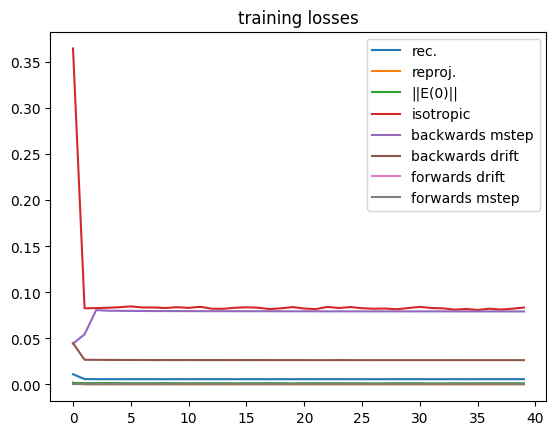

ENCODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


DECODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


LATENT DRIFT


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is <function uniform_ at 0x7fc085c77060>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is <function uniform_ at 0x7fc085c77060>


LATENT CONTROL


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is <function zeros_ at 0x7fc085c77420>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc

  2%|▎         | 1/40 [00:15<10:00, 15.41s/it]

ep 0: train 1.1202256679534912    test 2.8784966468811035
rec 1.059200644493103    mstep 0.06102309748530388    jac 0.0
horizon is now 2


  5%|▌         | 2/40 [00:29<09:19, 14.72s/it]

it: 2; avg reward: 0; completion rate: 0.0; gamma_max: 0


...

it: 36; avg reward: 0; completion rate: 0.0; gamma_max: 0


 95%|█████████▌| 38/40 [09:11<00:27, 13.84s/it]

it: 38; avg reward: 0; completion rate: 0.0; gamma_max: 0


100%|██████████| 40/40 [09:43<00:00, 14.59s/it]

ep 39: train 1.135115385055542    test 1.1426362991333008
rec 1.0217758417129517    mstep 0.11334004253149033    jac 0.0


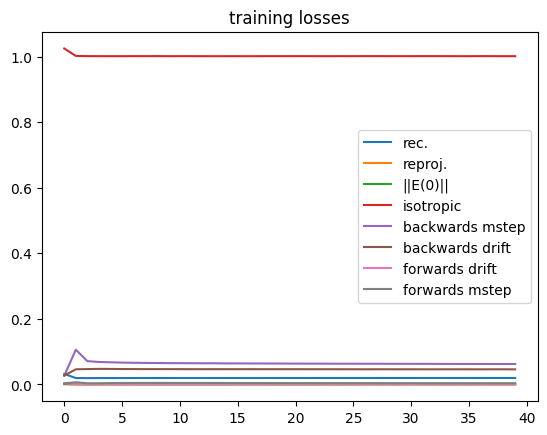

ENCODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


DECODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


LATENT DRIFT


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is <function uniform_ at 0x7fc085c77060>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is <function uniform_ at 0x7fc085c77060>


LATENT CONTROL


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is <function zeros_ at 0x7fc085c77420>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc

  2%|▎         | 1/40 [00:14<09:32, 14.68s/it]

ep 0: train 0.29477235674858093    test 2.0682618618011475
rec 0.27487123012542725    mstep 0.019901607185602188    jac 0.0
horizon is now 2


  5%|▌         | 2/40 [00:28<08:49, 13.94s/it]

21.517775
it: 2; avg reward: 448.35934957907057; completion rate: 0.62; gamma_max: 21.51777458190918
horizon is now 3


...

11.6220255
it: 36; avg reward: 358.8621710682859; completion rate: 0.69; gamma_max: 11.622025489807129


 95%|█████████▌| 38/40 [26:02<01:32, 46.02s/it]

10.26708
it: 38; avg reward: 282.27368814314576; completion rate: 0.75; gamma_max: 10.267080307006836


100%|██████████| 40/40 [27:53<00:00, 41.84s/it]

ep 39: train 0.19306215643882751    test 0.19293738901615143
rec 0.09197308868169785    mstep 0.10108909755945206    jac 0.0


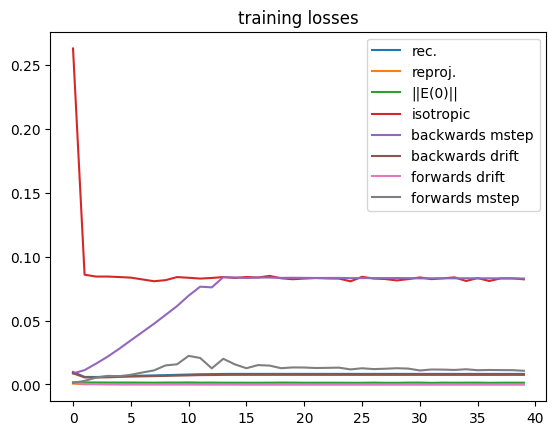

ENCODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


DECODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


LATENT DRIFT


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is <function uniform_ at 0x7fc085c77060>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is <function uniform_ at 0x7fc085c77060>


LATENT CONTROL


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is <function zeros_ at 0x7fc085c77420>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc

  2%|▎         | 1/40 [00:15<10:03, 15.46s/it]

ep 0: train 0.34926852583885193    test 1.9333466291427612
rec 0.33614689111709595    mstep 0.013121513649821281    jac 0.0
horizon is now 2


  5%|▌         | 2/40 [00:29<09:21, 14.78s/it]

14.9509
it: 2; avg reward: 264.454909638898; completion rate: 0.6; gamma_max: 14.950900077819824
horizon is now 3


...

9.093489
it: 36; avg reward: 320.3767219916083; completion rate: 0.73; gamma_max: 9.093488693237305


 95%|█████████▌| 38/40 [28:52<01:48, 54.31s/it]

10.346277
it: 38; avg reward: 374.3506267247701; completion rate: 0.77; gamma_max: 10.346277236938477


100%|██████████| 40/40 [31:02<00:00, 46.56s/it]

ep 39: train 0.15770018100738525    test 0.16021345555782318
rec 0.0925818383693695    mstep 0.06511819362640381    jac 0.0


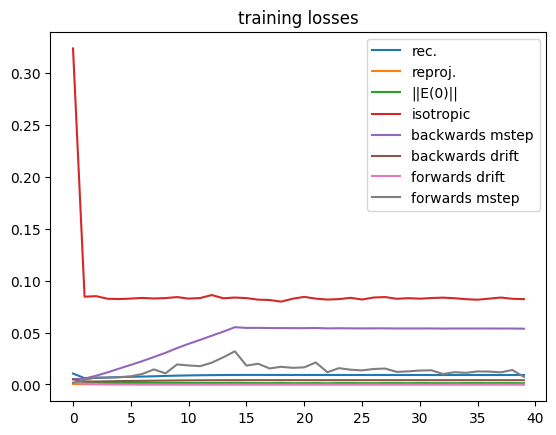

ENCODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


DECODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


LATENT DRIFT


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is <function uniform_ at 0x7fc085c77060>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is <function uniform_ at 0x7fc085c77060>


LATENT CONTROL


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is <function zeros_ at 0x7fc085c77420>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc

  2%|▎         | 1/40 [00:15<09:59, 15.38s/it]

ep 0: train 1.054302453994751    test 2.430699586868286
rec 1.0492089986801147    mstep 0.005093010142445564    jac 0.0
horizon is now 2


  5%|▌         | 2/40 [00:29<09:17, 14.68s/it]

16.59708
it: 2; avg reward: 300.80882008714434; completion rate: 0.83; gamma_max: 16.59708023071289
horizon is now 3


...

19.381304
it: 36; avg reward: 783.100362891035; completion rate: 1.0; gamma_max: 19.381303787231445


 95%|█████████▌| 38/40 [28:31<01:43, 51.85s/it]

19.90723
it: 38; avg reward: 851.0924586879675; completion rate: 1.0; gamma_max: 19.907230377197266


100%|██████████| 40/40 [30:35<00:00, 45.89s/it]

ep 39: train 0.1164727583527565    test 0.09625280648469925
rec 0.09215725213289261    mstep 0.024315427988767624    jac 0.0


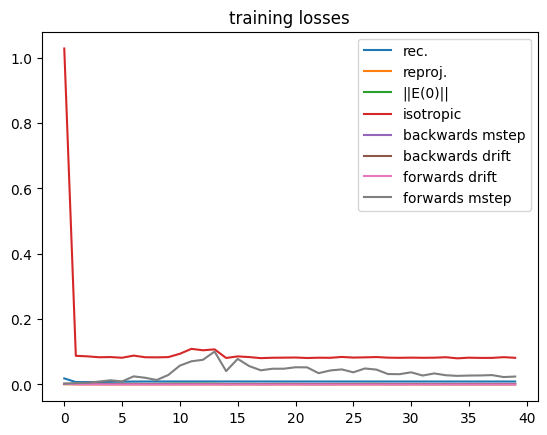

ENCODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


DECODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


LATENT DRIFT


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is <function uniform_ at 0x7fc085c77060>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is <function uniform_ at 0x7fc085c77060>


LATENT CONTROL


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is <function zeros_ at 0x7fc085c77420>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc

  2%|▎         | 1/40 [00:14<09:34, 14.72s/it]

ep 0: train 0.3997507691383362    test 1.875229001045227
rec 0.3828236758708954    mstep 0.016928117722272873    jac 0.0
horizon is now 2


  5%|▌         | 2/40 [00:27<08:45, 13.83s/it]

24.790043
it: 2; avg reward: 505.92935905203143; completion rate: 0.88; gamma_max: 24.790042877197266
horizon is now 3


...

13.938711
it: 36; avg reward: 653.7593077390436; completion rate: 0.96; gamma_max: 13.938711166381836


 95%|█████████▌| 38/40 [29:05<01:48, 54.28s/it]

13.961255
it: 38; avg reward: 538.8555578687727; completion rate: 0.97; gamma_max: 13.961255073547363


100%|██████████| 40/40 [31:17<00:00, 46.93s/it]

ep 39: train 0.18139806389808655    test 0.1548292189836502
rec 0.09420444071292877    mstep 0.08719362318515778    jac 0.0


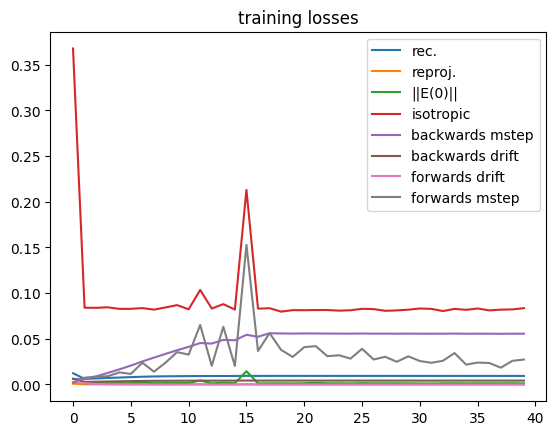

ENCODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


DECODER


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is nn.init.zeros


LATENT DRIFT


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is <function uniform_ at 0x7fc085c77060>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is <function uniform_ at 0x7fc085c77060>


LATENT CONTROL


### Layer 0 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc085c776a0>
g bias init is <function zeros_ at 0x7fc085c77420>


### Layer 1 ###
Not residual
g init is <function xavier_uniform_ at 0x7fc

  2%|▎         | 1/40 [00:15<09:58, 15.35s/it]

ep 0: train 0.34385019540786743    test 2.1026697158813477
rec 0.3178257644176483    mstep 0.02602415904402733    jac 0.0
horizon is now 2


  5%|▌         | 2/40 [00:29<09:17, 14.66s/it]

10.947871
it: 2; avg reward: 273.926893809051; completion rate: 0.56; gamma_max: 10.947871208190918
horizon is now 3


...

9.899028
it: 36; avg reward: 364.438801868894; completion rate: 0.63; gamma_max: 9.899027824401855


 95%|█████████▌| 38/40 [25:02<01:26, 43.44s/it]

9.366549
it: 38; avg reward: 282.6119334028521; completion rate: 0.72; gamma_max: 9.366548538208008


100%|██████████| 40/40 [26:46<00:00, 40.16s/it]

ep 39: train 0.2001250833272934    test 0.20545364916324615
rec 0.09153533726930618    mstep 0.10858967155218124    jac 0.0


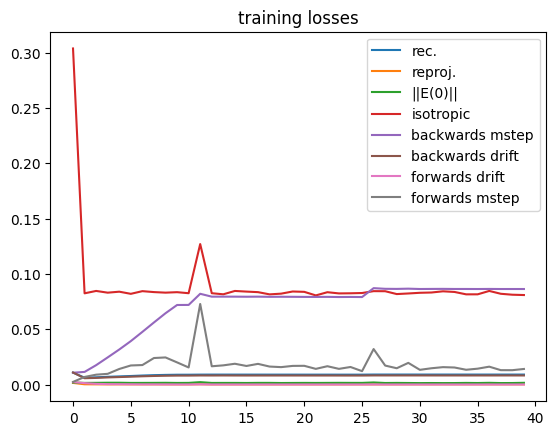

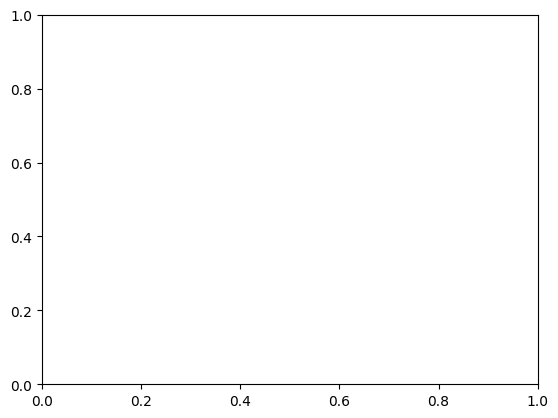

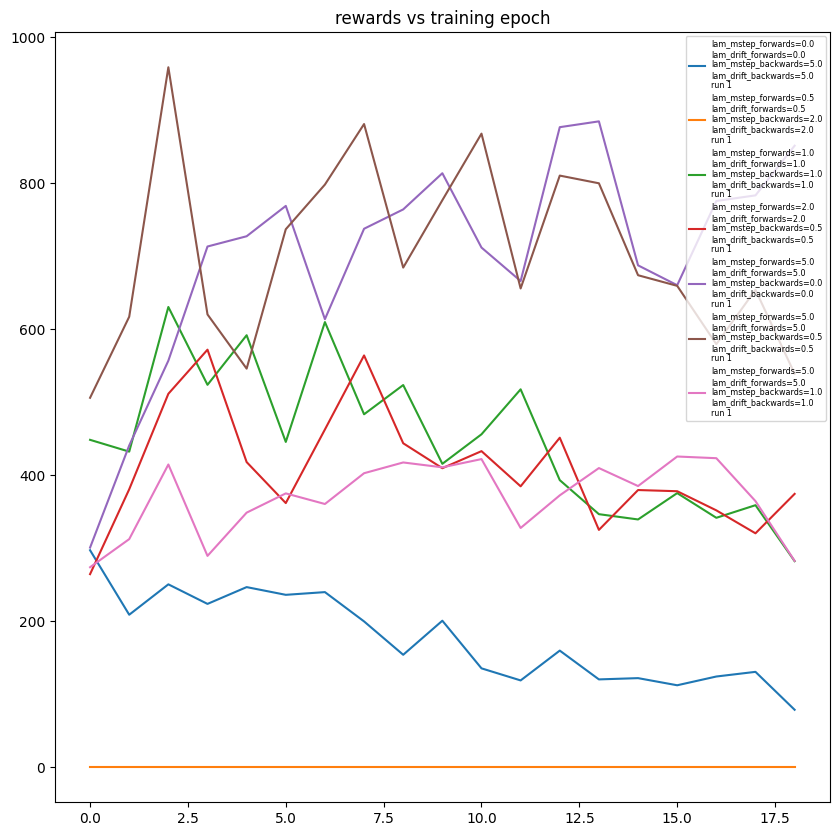

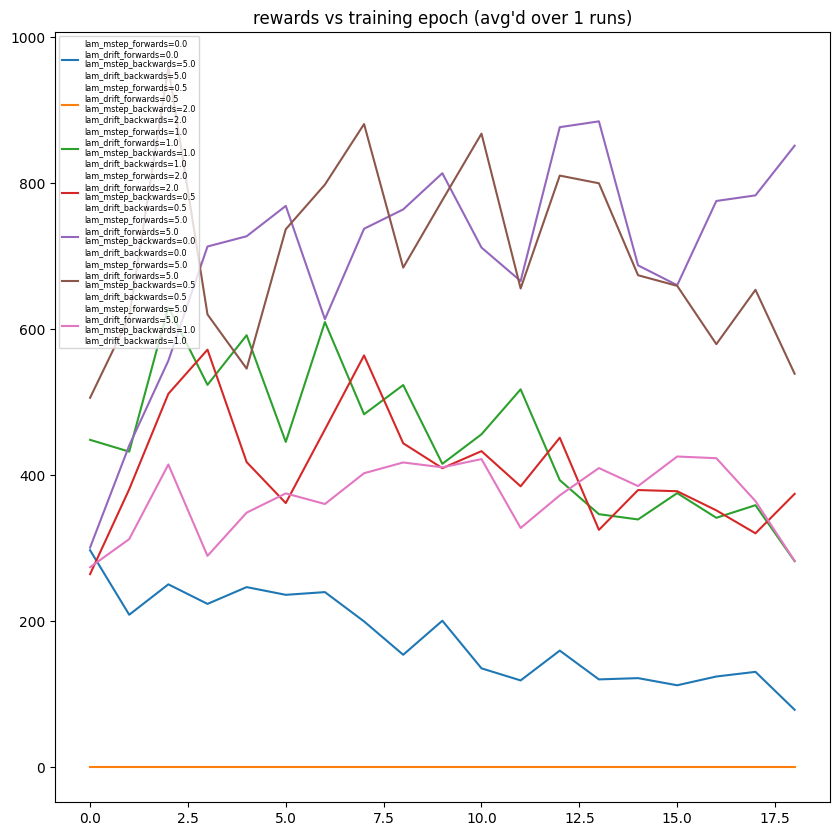

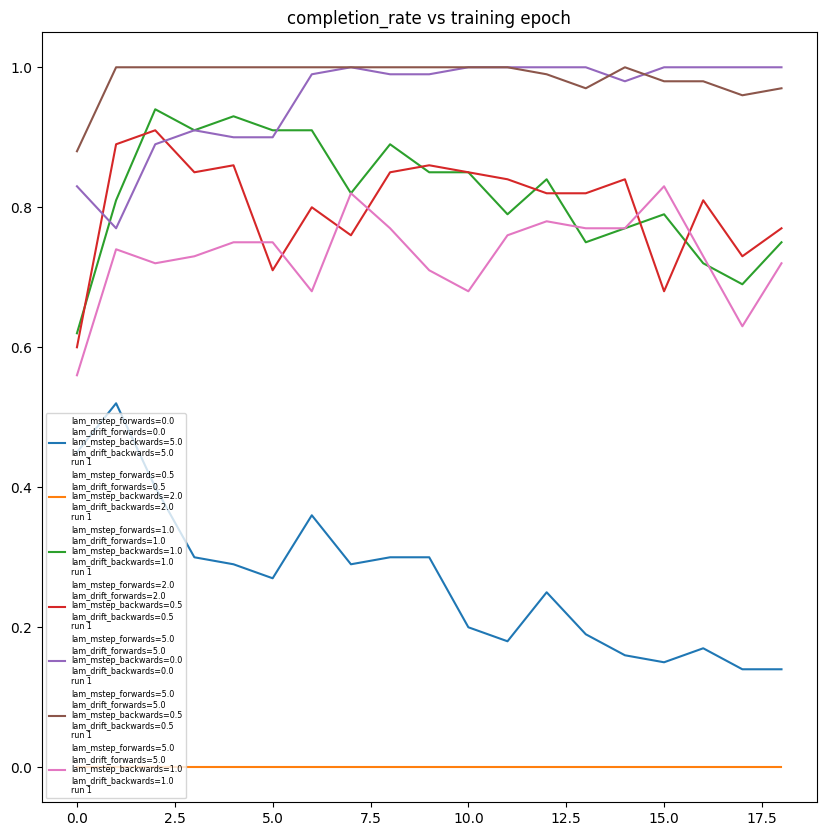

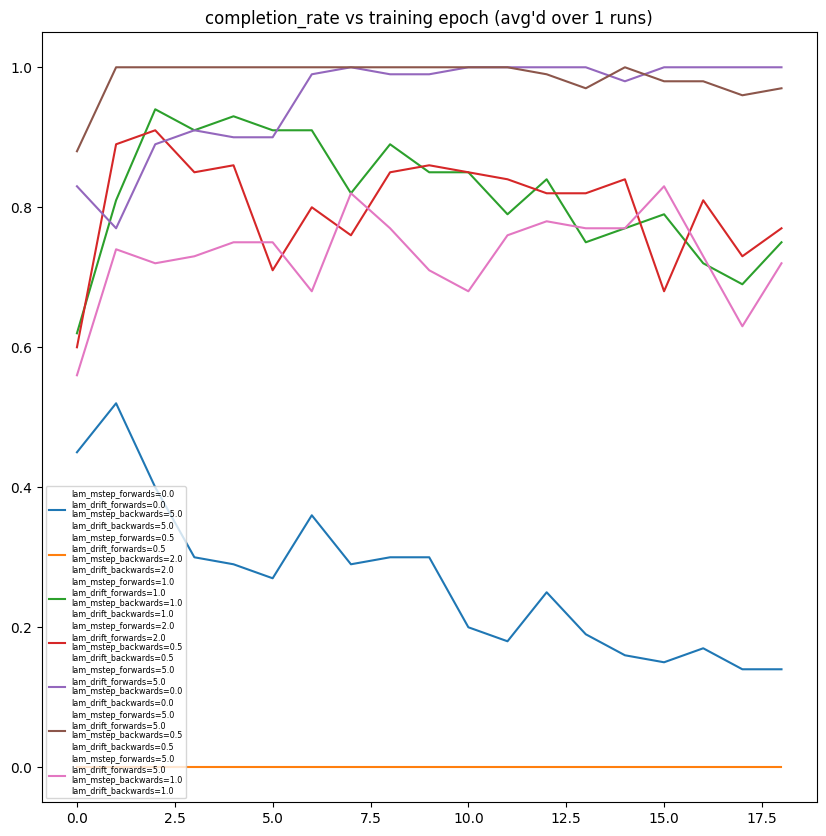

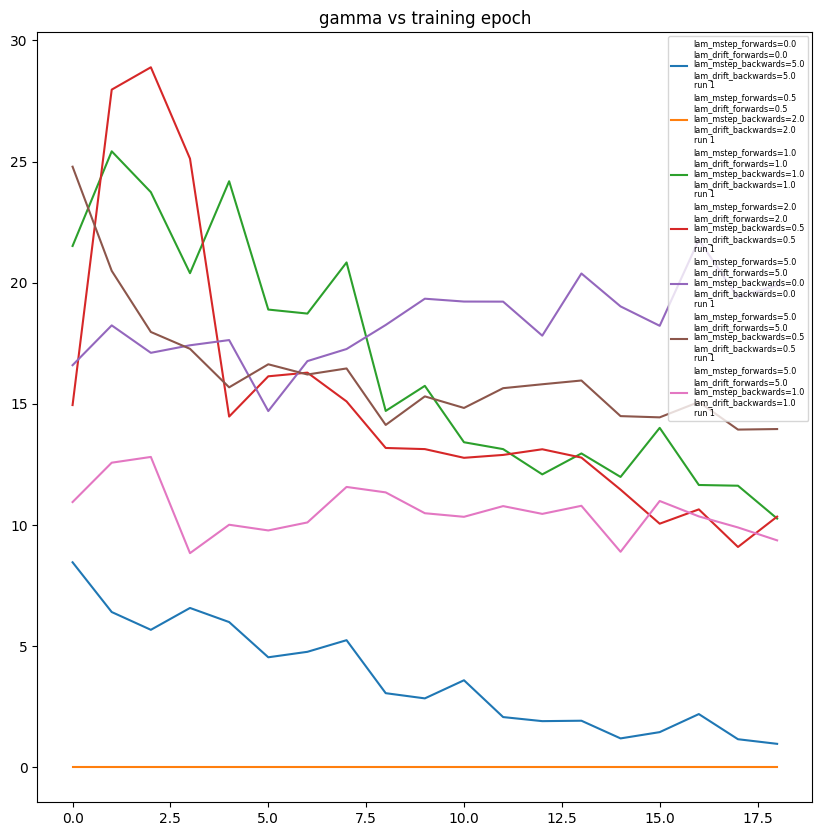

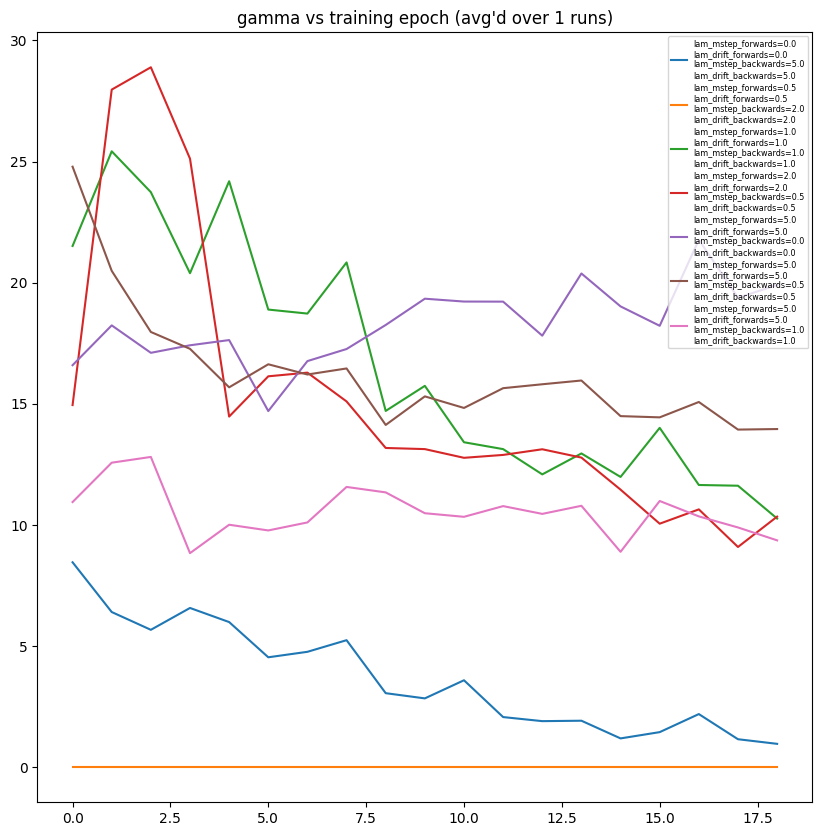

final state
 [5, 5, 1, 1]
saving fwd_bwd_sweep.pkl


In [3]:
#####################################
### Run Experiment to Train Model ###
#####################################

from experiments import run_experiment_new

name = 'fwd_bwd_sweep'#'normalized'
#spec = {'symbols': [(0,1,2,3), (0, 1, 3), (1, 2, 3), (1, 3)],
#        'ignored': [(), (2,), (0,), (0, 2)]}
spec = {'lam_mstep_forwards':  [0., 0.5, 1., 2., 5., 5., 5.,],
        'lam_drift_forwards':  [0., 0.5, 1., 2., 5., 5., 5.,],
        'lam_mstep_backwards': [5., 2., 1., 0.5, 0., 0.5, 1.],
        'lam_drift_backwards': [5., 2., 1., 0.5, 0., 0.5, 1.],}
#n_runs = [1, 1, 1, 0]
n_runs = 7*[1]
exp=run_experiment_new(data, spec, plot=True, n_runs=n_runs, fname=name, save=True)

In [4]:
#######################
### Save Experiment ###
#######################

save_name = name
save_experiment(save_name, exp)

saving fwd_bwd_sweep.pkl


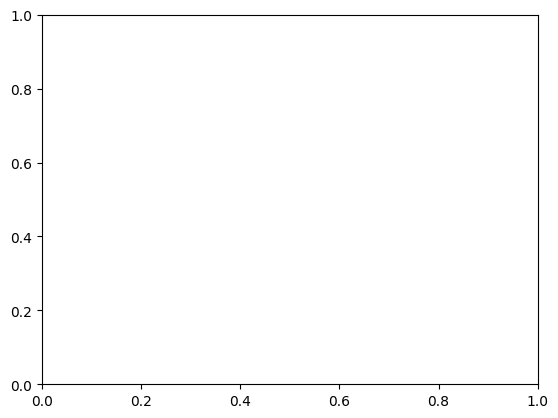

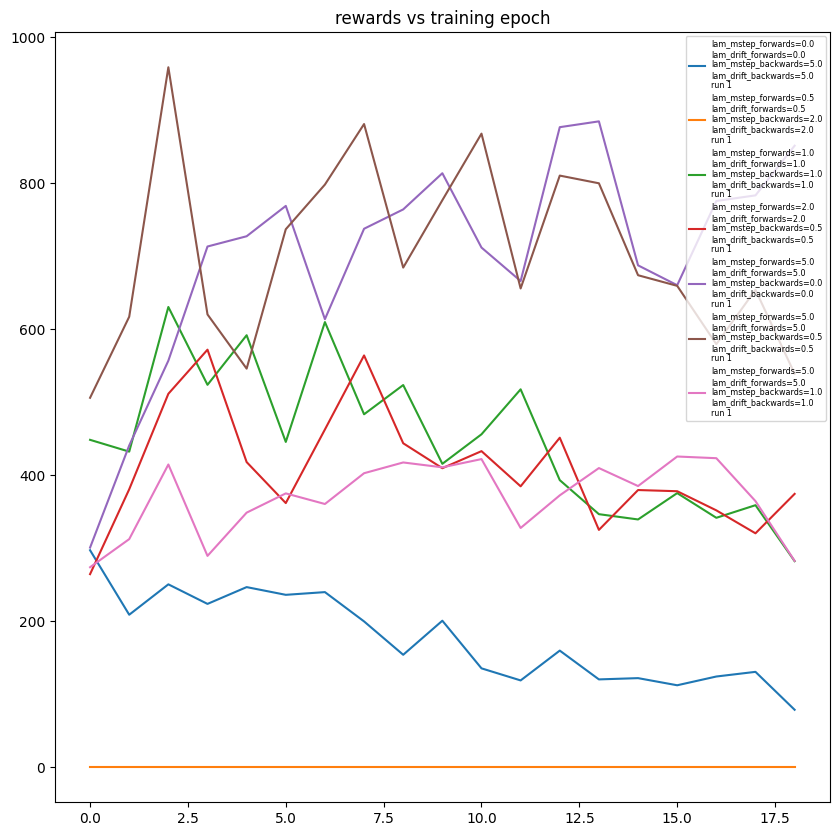

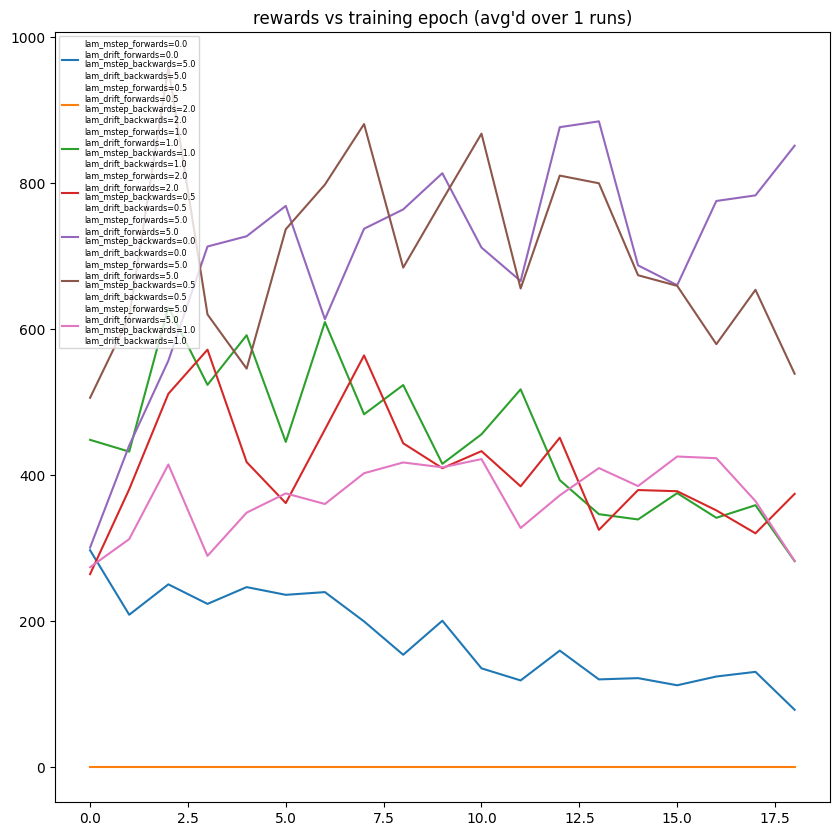

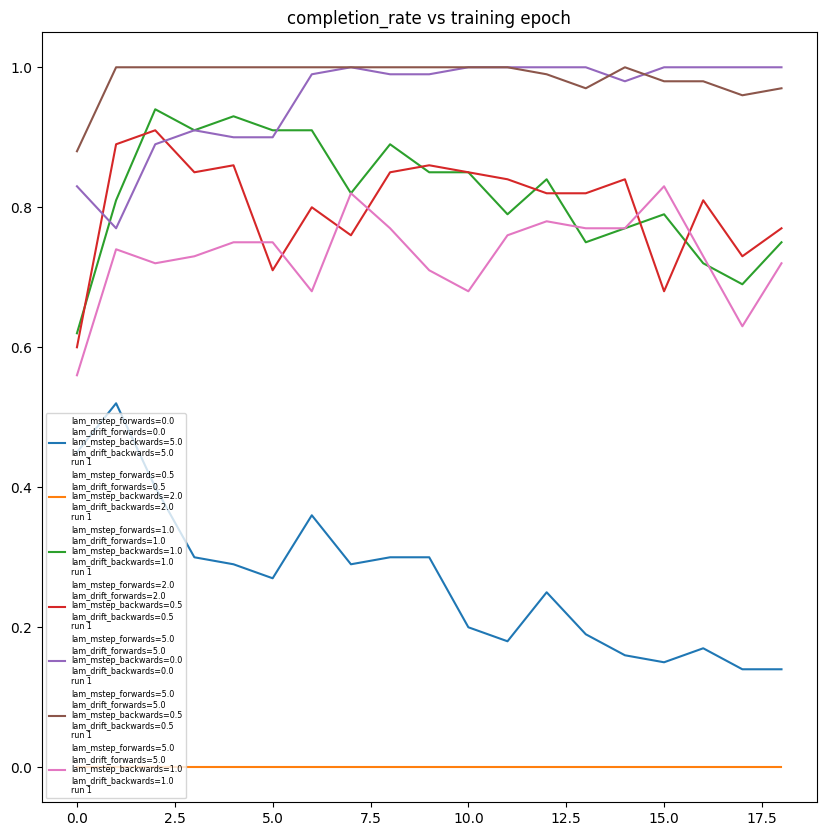

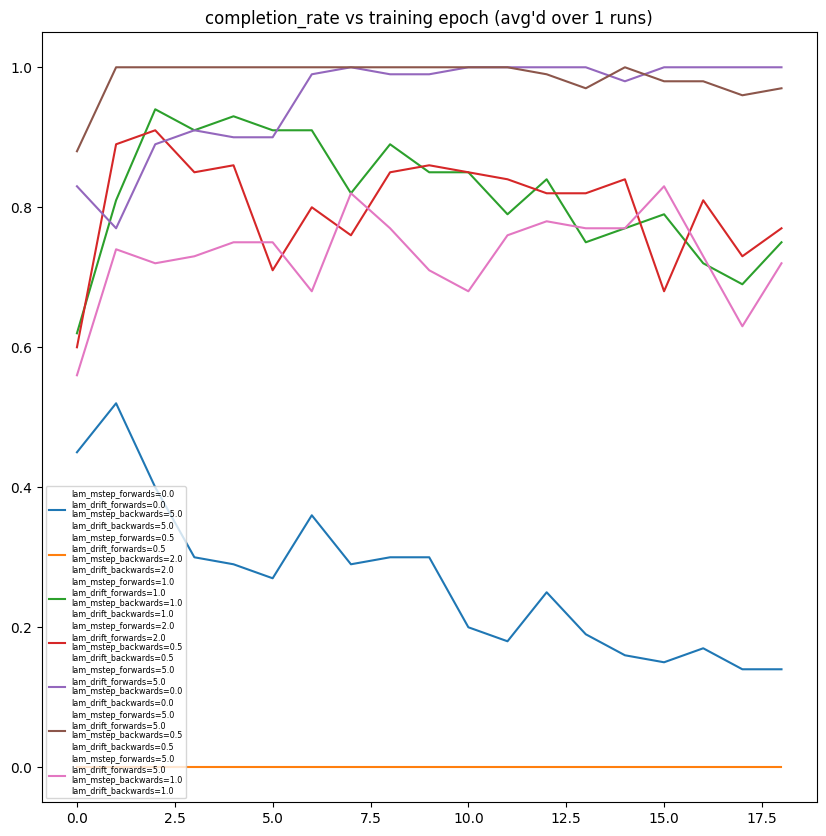

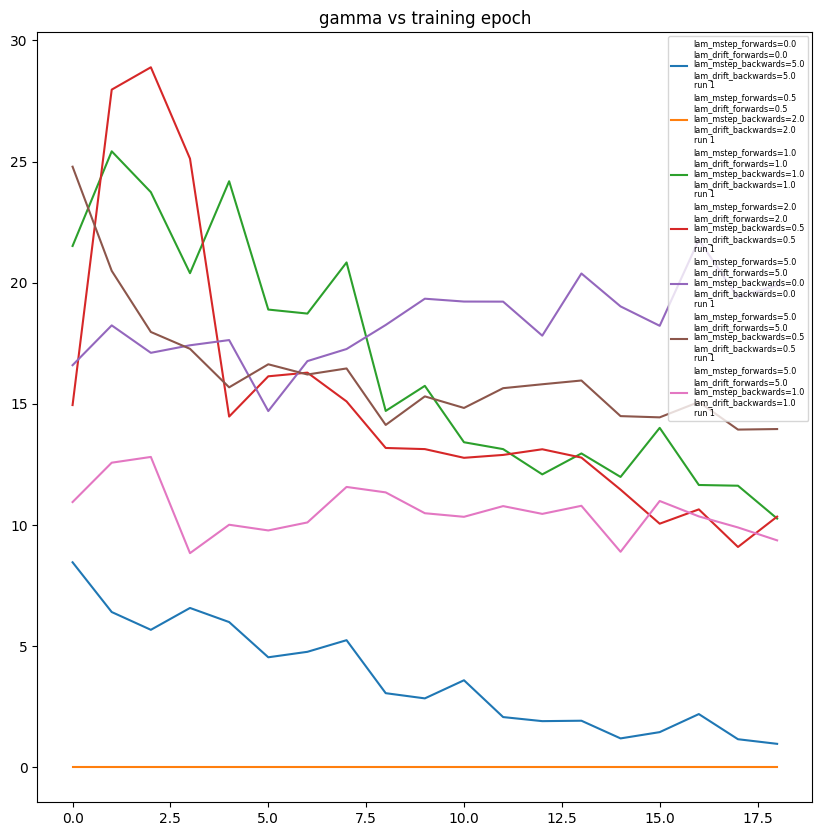

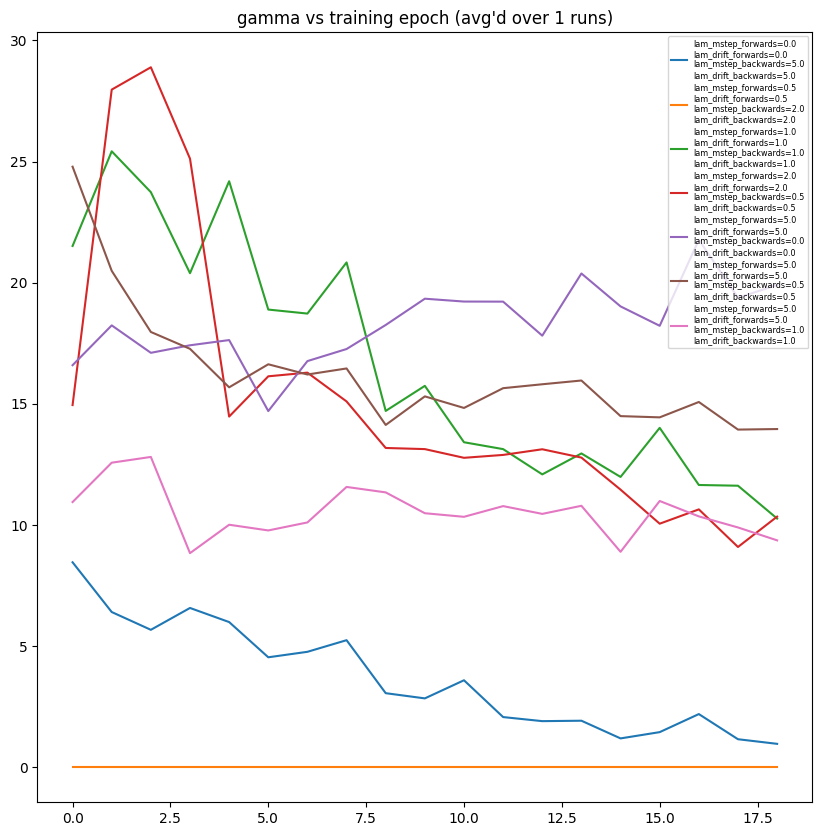

In [55]:
#######################
### Load Experiment ###
#######################

#name = 'reference_model'
#name = 'normalized_singleExp_longRun_2'
exp = load_experiment(name)
plot_experiment_new(exp)

In [47]:
###############################
### Choose Model Checkpoint ###
###############################

config_idx = 6
run_idx = 0

best_model_idx = np.argmax(exp['completion_rate'][config_idx][1][run_idx])
#best_model_idx = np.argmin(exp['gamma'][config_idx][1][run_idx])
#best_model_idx = 90 #-1

ae = exp['ae_list'][config_idx][1][run_idx][best_model_idx]
fdyn = exp['fdyn_list'][config_idx][1][run_idx][best_model_idx]
ae.encode(torch.tensor([0.,0.,0.,0.]))

tensor([-0.0005,  0.0002], device='cuda:0', grad_fn=<ViewBackward0>)

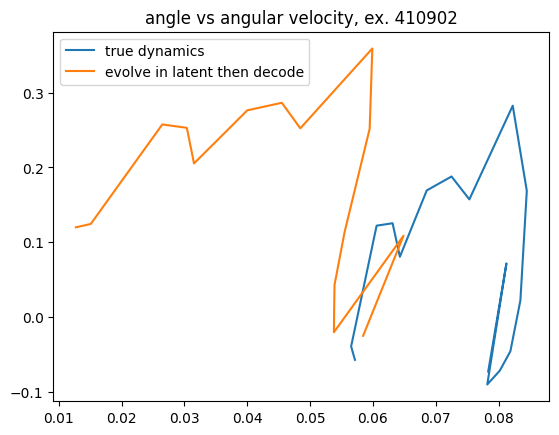

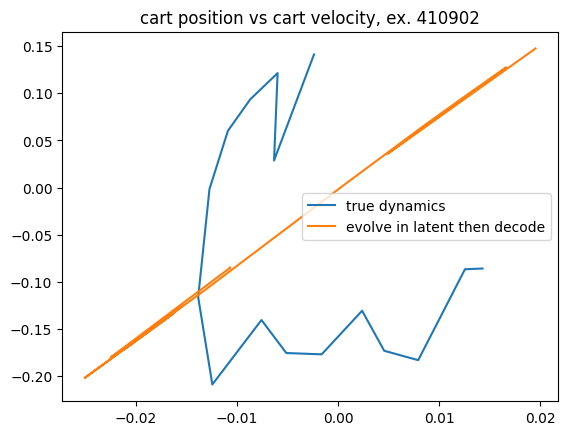

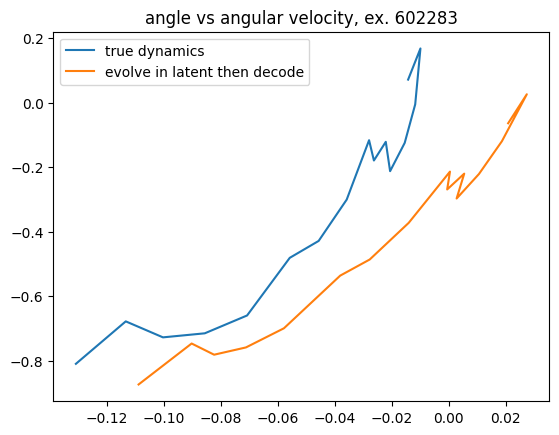

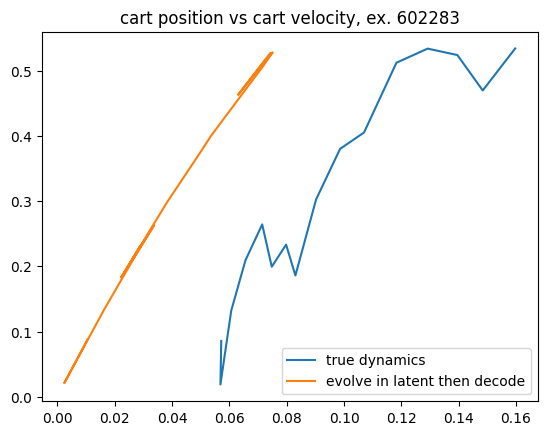

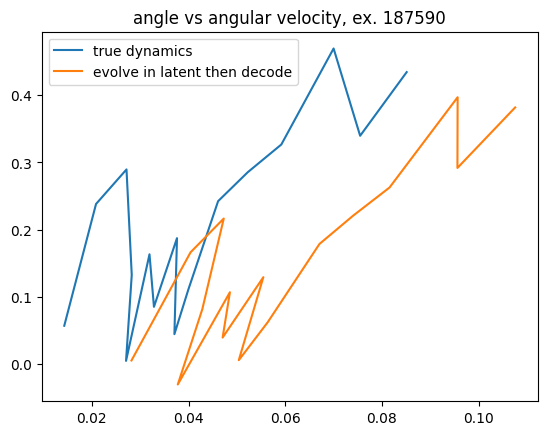

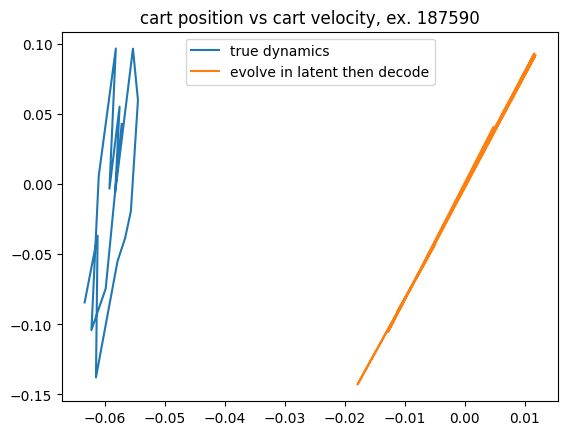

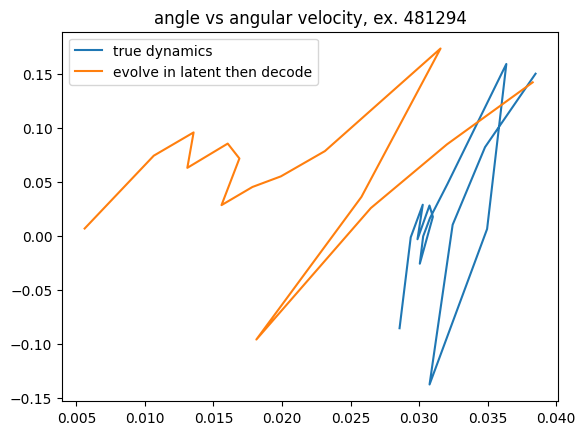

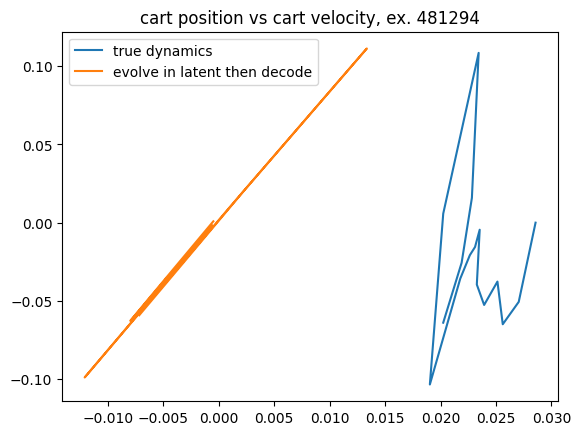

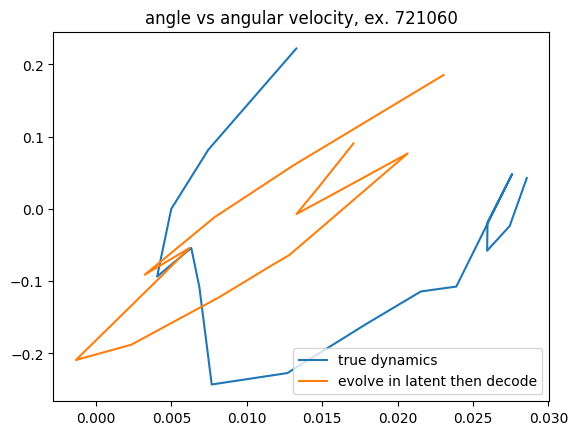

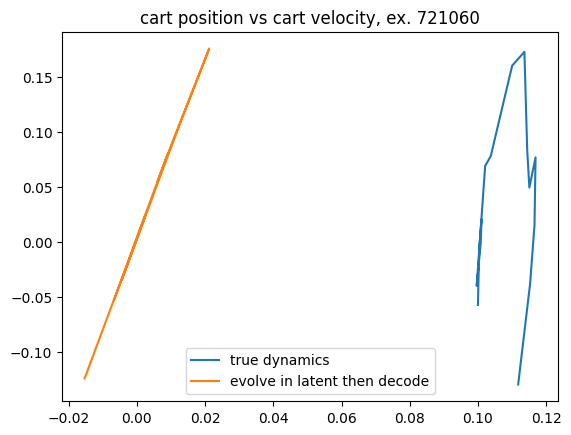

In [48]:
#######################################
### Plot Reconstructed Trajectories ###
#######################################

plot_trajectories(ae, fdyn, Xtest[0], Utest[0], 5, steps=params.traj_len)

z_eq tensor([[0.0001, 0.0013]], device='cuda:0', grad_fn=<AddmmBackward0>)


100%|██████████| 500/500 [00:58<00:00,  8.60it/s]


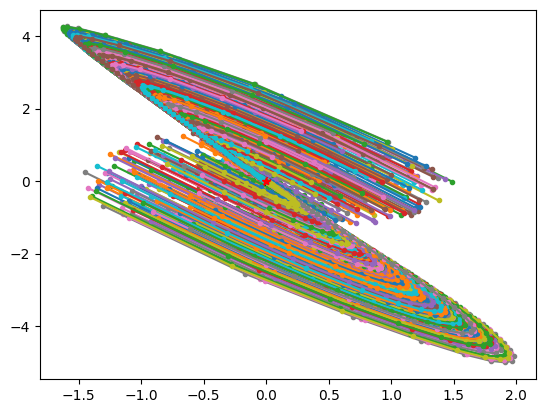

100%|██████████| 500/500 [00:52<00:00,  9.51it/s]


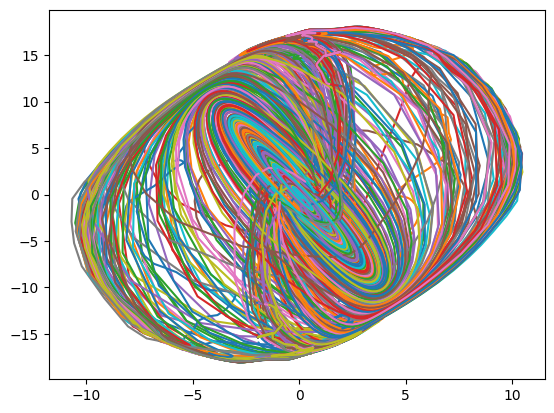

max x: 1538.1684263501343
max v: 505.68358006305954
max theta: 86.81091237954261
max w: 29.04402333935528


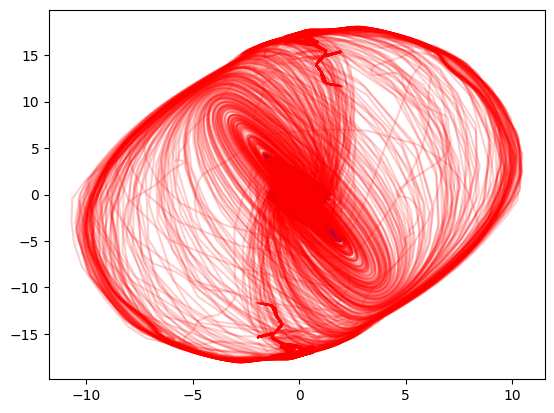

x data (500, 301, 4)
z data (500, 301, 2)
z proj data (500, 301, 2)
u data (500, 300, 1)
gamma forward 21.917751
gamma backward 1618.4988


In [18]:
####################################
### Initialize Data for Lyapunov ###
####################################

from plotting import plot_latent_trajectories
from utils import rollout_trajectories

r = 1.2e-1 
r_test = r 
rz_init = 1.50 
n_traj = 500 #3000 
T = 300
b = ae.encode(torch.tensor(4*[0.,])).cpu().detach().numpy()

for u_cost in [1]:
    lqr = LQR(ae, fdyn, u_cost=u_cost)
    pts, z_data, x_init_cond = plot_latent_trajectories(ae, fdyn, rz_init, n_traj, T=T, plot_quadratic=False, origin_spec=(b, r), lqr=lqr) #r=0.05
    x_data, z_proj_data, u_data, gammas = rollout_trajectories (ae, fdyn, lqr, x_init_cond, plot=True, n_traj=n_traj, T=T)
    gamma_fwd, gamma_bwd = gammas
    
    for zi in z_data:
        plt.plot(zi[:,0], zi[:,1], 'b-')
    for zi in z_proj_data:
        plt.plot(zi[:,0], zi[:,1], 'r-', alpha=0.2)
    plt.show()
    
    u_data = u_data[...,np.newaxis]
    
    print("x data", x_data.shape)
    print("z data", z_data.shape)
    print("z proj data", z_proj_data.shape)
    print("u data", u_data.shape)
    print("gamma forward", gamma_fwd)
    print("gamma backward", gamma_bwd) 

In [58]:
from utils import rollout_parallel_rk4

Dx_parallel = rollout_parallel_rk4(ae, fdyn, lqr, x_init_cond, save=True)
print(Dx_parallel.shape)
print(Dx_parallel[0,-1])
DE = torch.func.jacfwd(ae.encoder)
for i in range(5):
    print("DE:", i)
    print(DE(torch.tensor(Dx_parallel[i,75])))j

100%|██████████| 1000/1000 [00:01<00:00, 591.21it/s]


(500, 1001, 4)
[-1.4349159e+04 -1.3044625e+03  1.7983552e+00  1.5443439e-02]
DE: 0
tensor([[ 0.0128, -0.0148, -0.1203, -0.0031],
        [-0.0050,  0.0059,  0.0517, -0.0009]], device='cuda:0',
       grad_fn=<ViewBackward0>)
DE: 1
tensor([[ 0.0102, -0.0124, -0.1099, -0.0006],
        [-0.0042,  0.0051,  0.0482, -0.0016]], device='cuda:0',
       grad_fn=<ViewBackward0>)
DE: 2
tensor([[ 0.0073, -0.0108, -0.1206,  0.0042],
        [-0.0034,  0.0047,  0.0526, -0.0031]], device='cuda:0',
       grad_fn=<ViewBackward0>)
DE: 3
tensor([[ 0.0107, -0.0144, -0.1423,  0.0014],
        [-0.0044,  0.0058,  0.0596, -0.0023]], device='cuda:0',
       grad_fn=<ViewBackward0>)
DE: 4
tensor([[ 0.0077, -0.0115, -0.1292,  0.0043],
        [-0.0035,  0.0049,  0.0555, -0.0032]], device='cuda:0',
       grad_fn=<ViewBackward0>)


z_eq: tensor([-0.0005,  0.0002], device='cuda:0', grad_fn=<ViewBackward0>)
pd loss: False
dyn loss: True
lb loss False
grad loss False
rho: 0.85
c lb 0.1
l_dyn 1
l_pd 1
l_lb 1
l_grad 1e-06
using grid data, grid_density: 100
features: 256
coeff: 0.1
LyapunovGeneral(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=256, bias=False)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=256, bias=False)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=1, bias=False)
  )
)
it 0: tensor([280.4275], device='cuda:0', grad_fn=<AddBackward0>)
it 1000: tensor([7.5470], device='cuda:0', grad_fn=<AddBackward0>)
it 2000: tensor([0.8439], device='cuda:0', grad_fn=<AddBackward0>)
it 3000: tensor([0.4845], device='cuda:0', grad_fn=<AddBackward0>)
it 4000: tensor([0.5892], device='cuda:0', grad_fn=<AddBackward0>)
alpha 180.89932250976562
torch.Size([150500, 2])
Lipschitz constant tensor(225.8566, device='cuda:0', grad_fn=<MaxBackward1>)


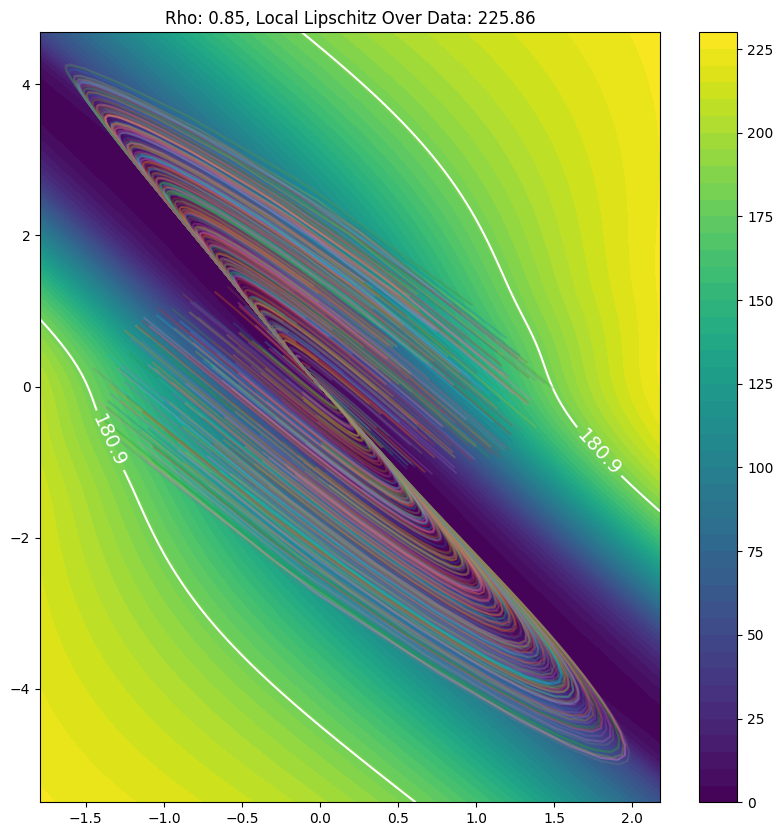

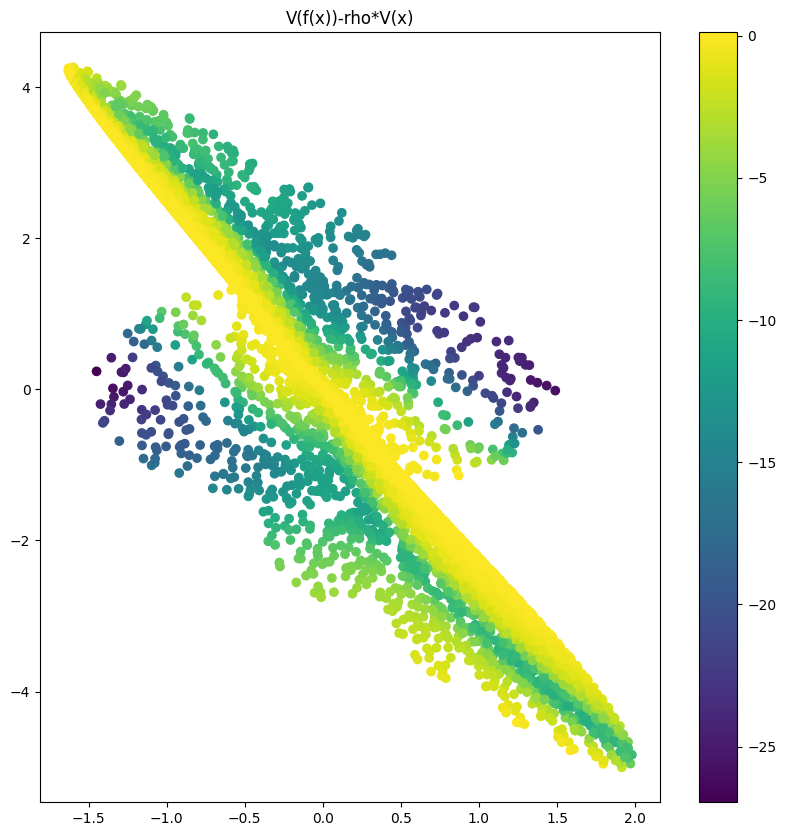

In [69]:
###############################
### Learn Lyapunov Function ###
###############################

from controls import mlp_lyapunov_reparam
from experiments import load_experiment
from theorem_tools import plot_violation

z_eq = ae.encode(torch.tensor([0.,0.,0.,0]).float())
print("z_eq:", z_eq)
rho = 0.85 
features = 256
parameterization = "general" 
lyap_training_epochs = int(5e3) #3e4
V, rho, alpha, lip = mlp_lyapunov_reparam(z_data, epochs=lyap_training_epochs, lr=2e-4, grid_dens=100, rho=rho, z_eq=z_eq, parameterization=parameterization, features=256) #ep 0.5e4
plot_violation(V, rho, torch.tensor(z_data), ae, lip.item(), gamma_fwd, alpha/6, plot_contours=False)

In [ ]:
from animation_utils import animate

animate(V, ae, [0, 1], [-1, 1, -1, 1], 2, [-2, 2], 3, 0., n_per_axis=1000)


Generating animation...


In [21]:
############################################################
### Compute Preimage by Sampling from Invariant Manifold ###
############################################################

#Dx = compute_preimage(ae, z_data, 0.75, 7, uniform_sampling=True, X=manifold, n_samples=int(4e4), eps=0.01) # n_samples=1e4, eps=0.01
Dx = compute_preimage(ae, z_data, 0.75, 7, uniform_sampling=True, X=manifold, n_samples=int(300), eps=0.01) # n_samples=1e3, eps=0.01

(253, 4)


100%|██████████| 10/10 [00:37<00:00,  3.78s/it]


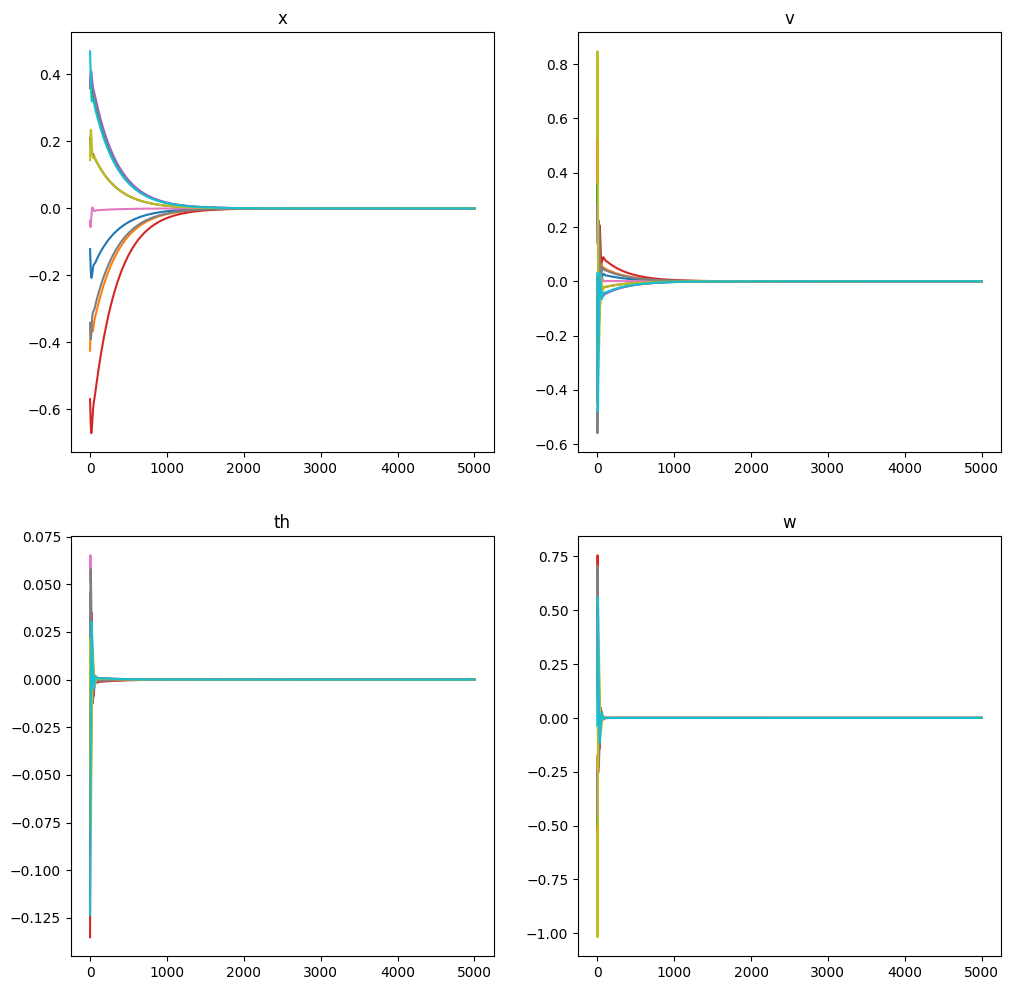

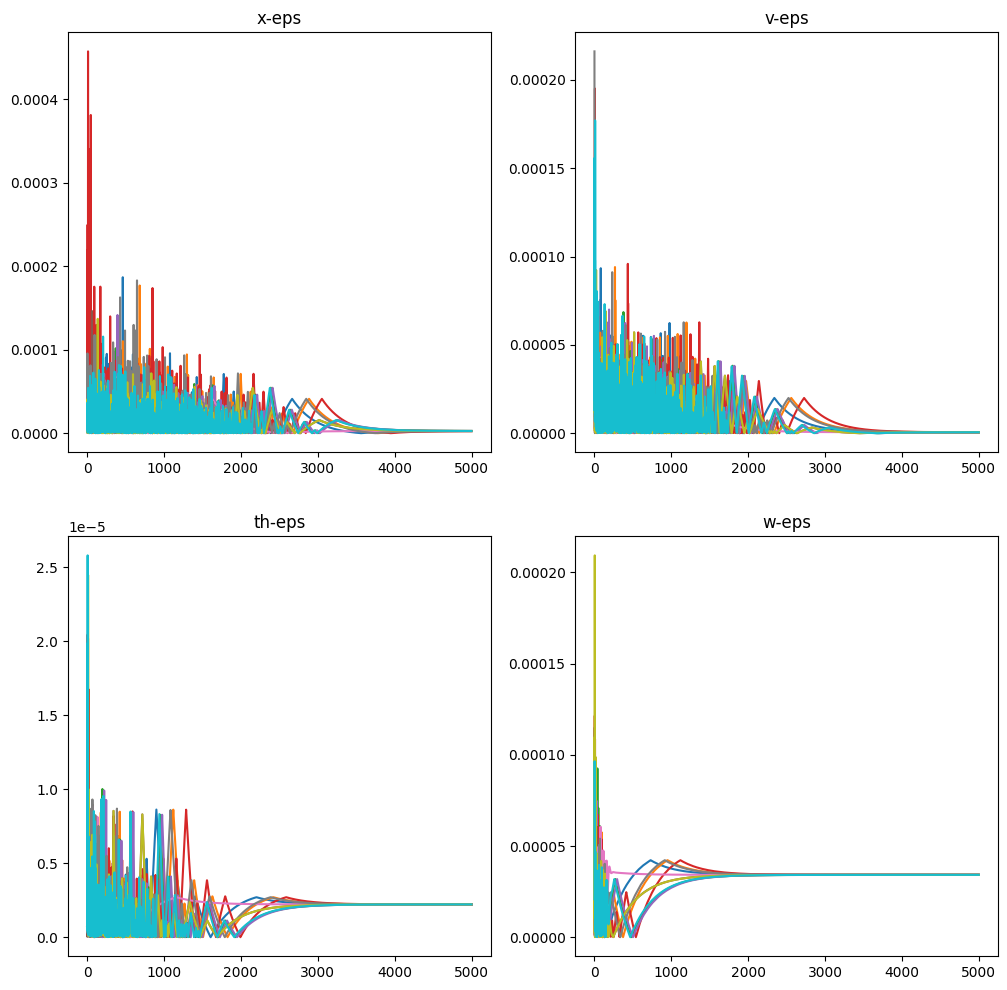

In [22]:
################################################
### Inspect Invariance of Invariant Manifold ###
################################################

print(Dx.shape)
#_ = verify_invariance(ae, fdyn, T=60, stabilize=True, X0=Dx[0:250], manifold=manifold)
_ = verify_invariance(ae, fdyn, T=5000, stabilize=True, X0=Dx[0:10], manifold=manifold)

(253, 4)
159.9709930419922
k_eval: [  2   3   4   5   6   7   8   9  10 200]


  0%|          | 0/253 [00:00<?, ?it/s]/home1/lutkus/.conda/envs/latent-space/lib/python3.13/site-packages/torch/utils/_device.py:104: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)
100%|██████████| 253/253 [02:02<00:00,  2.06it/s]


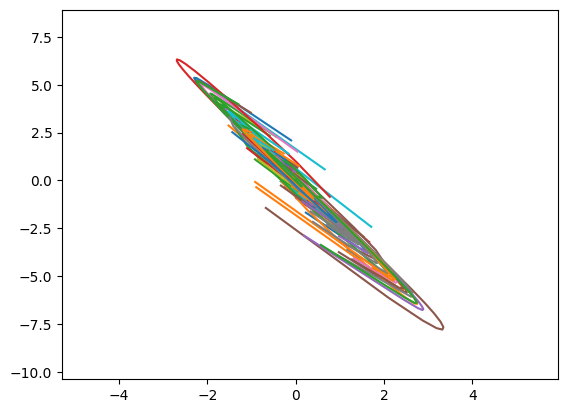

max x: 0.8952181935310364
max v: 1.8351711344923731
max theta: 0.41557517647743225
max w: 2.581355865913328
gamma fwd: 0.94353557
L: 256.99676513671875
a0: 479.91297912597656
rho: 0.85
Ly/(1-p): 1616.5706
R: 83.15534210205078
k: [  2   3   4   5   6   7   8   9  10 200]
gamma_k forward: [1.9659299e+00 3.5356059e+00 8.8461857e+00 5.2754971e+01 3.0924683e+02
 2.7663647e+03 2.9771467e+04 5.6816031e+05 1.0282471e+07 1.7163644e-02]
Ly_k/(1-p^k): [1.82067607e+03 2.35475033e+03 4.75621525e+03 2.43717166e+04
 1.27599544e+05 1.04639805e+06 1.05169359e+07 1.90029386e+08
 3.29034687e+09 4.41100073e+00]
xticks arg 1 [ 0  1  2  3  4  5  6  7  8  9 10]
mid [  2   3   4   5   6   7   8   9  10 200]
xticks arg 2 [1, np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(200)]


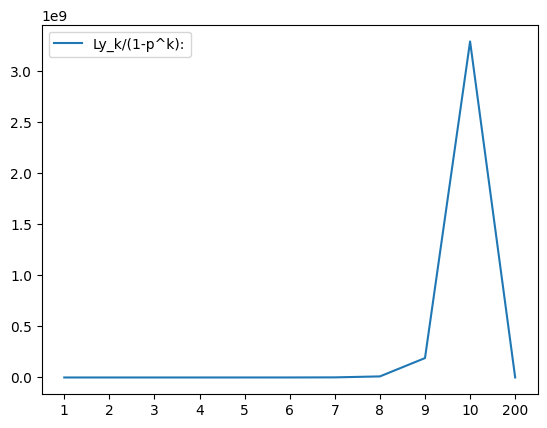

100%|██████████| 253/253 [01:30<00:00,  2.79it/s]


max x: 0.8952181935310364
max v: 1.8351711344923731
max theta: 0.41557517647743225
max w: 2.581355865913328


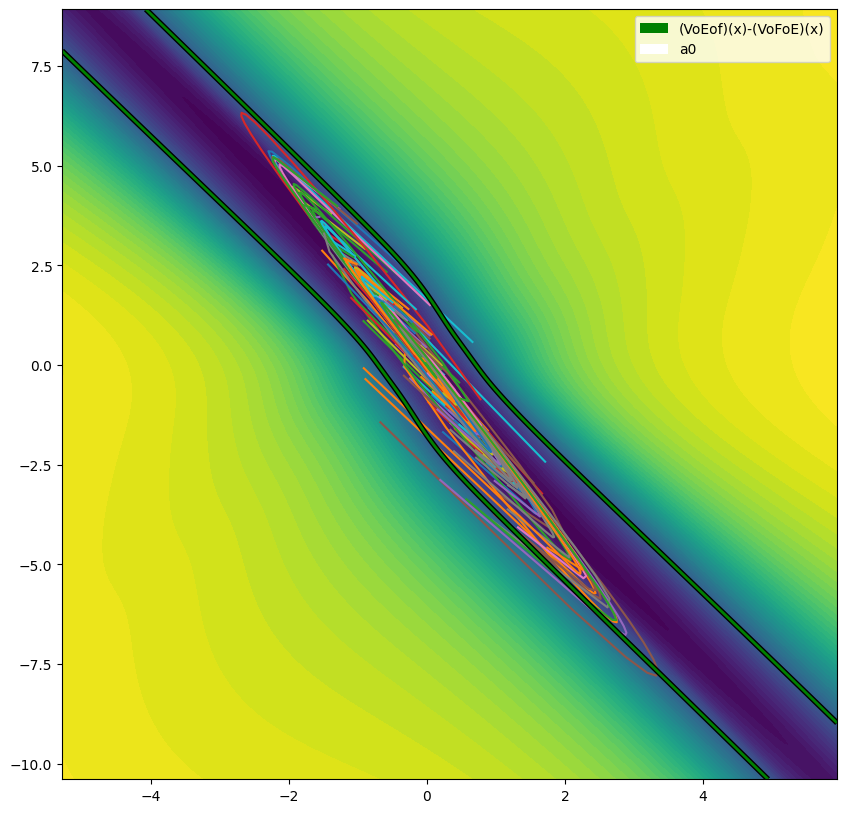

In [24]:
##################################################################
### Compute Ly/p and Levelsets over Trajectories from Preimage ###
##################################################################

a0 = torch.max(V(ae.encode(torch.tensor(Dx)))).cpu().item()
print(Dx.shape)
print(a0)
Dz = z_data
#Dxtraj, gamma, L, res = plot_lyapunov_lvlsets(V, ae, fdyn, Dx, Dz, a0/6, rho, only_rollout=False, n_per_axis=175)
Dxtraj, gamma, L, res = plot_lyapunov_lvlsets(V, ae, fdyn, Dx, Dz, 3*a0, rho, only_rollout=False, n_per_axis=175) #a0/6

In [ ]:
##################################################################
### Plot Violation of Lyapunov Condition for E(x) Trajectories ###
##################################################################

from theorem_tools import plot_violation, verify_invariance
plot_violation(V, rho, torch.tensor(Dxtraj), ae, gamma, L, a0/6) #a0/6

100%|██████████| 4/4 [00:00<00:00,  5.85it/s]


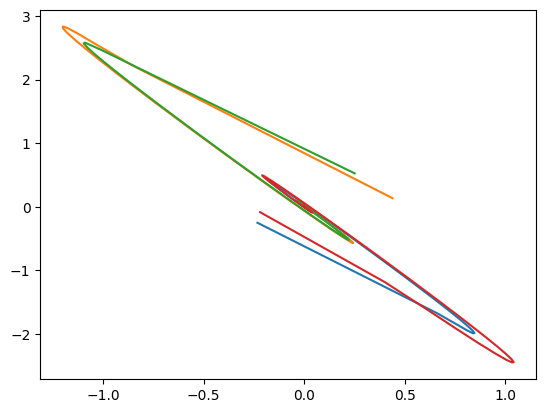

max x: 0.14405871941547552
max v: 0.5399505458329358
max theta: 0.15
max w: 0.7368668975142837


100%|██████████| 3500/3500 [00:05<00:00, 610.29it/s]


x-theta traj: (4, 501, 4)


100%|██████████| 15000/15000 [00:03<00:00, 4859.79it/s]
/home1/lutkus/.conda/envs/latent-space/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


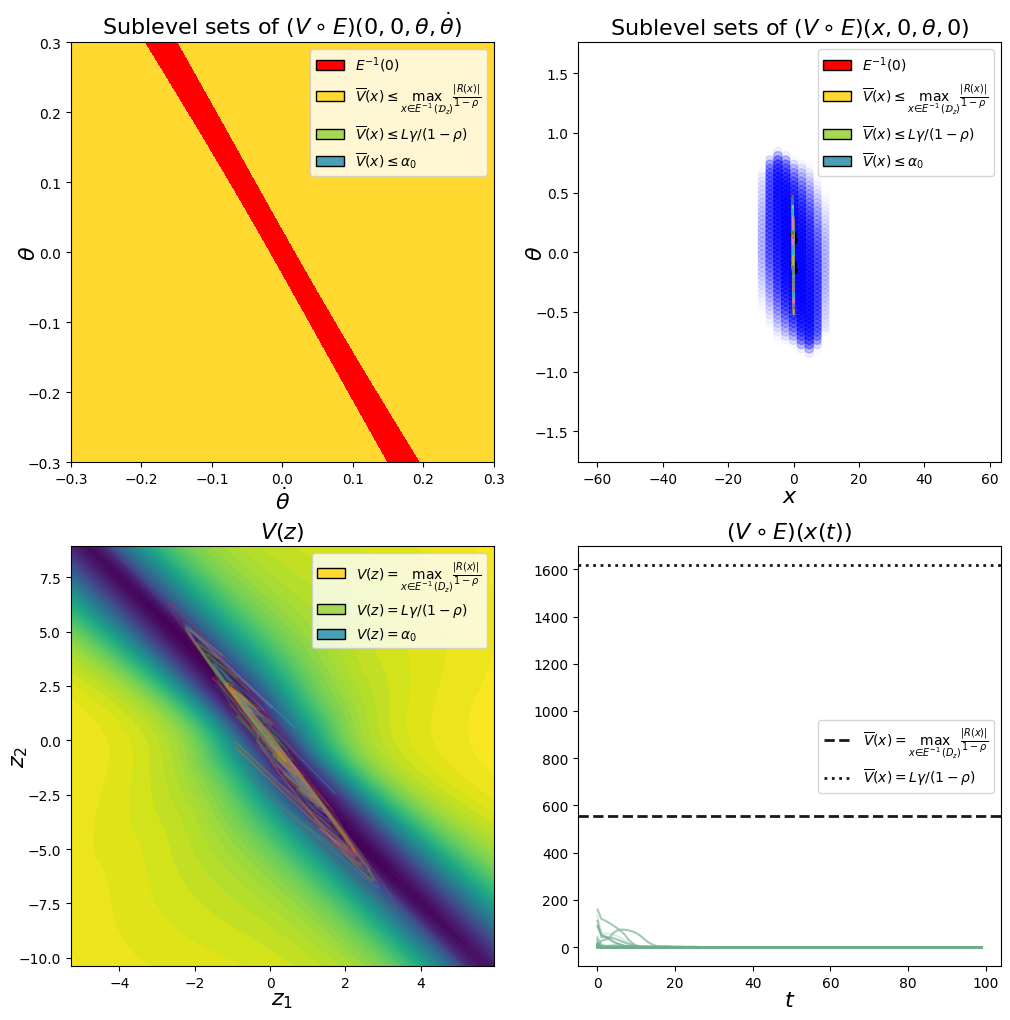

In [29]:
###################
### Make Figure ###
###################

from plotting import plot_lyapunov_slice
from theorem_tools import plot_figure_final
from utils import rollout_trajectories

lqr = LQR(ae, fdyn)

#r_plot = 0.2 
r_plot = 0.3
X0_extra = np.array([[-0.05, 0.05, -0.1, 0.0],
                     [-0.075, -0.1, 0.15, 0.05],
                     [0.0, 0.0, 0.1, 0.0],
                     [0.0, 0.1, -0.15, 0.05]])

X_extra, _, _, _ = rollout_trajectories(ae, fdyn, lqr, X0_extra, T=500) #T=2000
#X_extra, _, _, _ = rollout_trajectories(ae, fdyn, lqr, Dx[:1000], T=500)
#plot_figure_final(V, ae, Dxtraj, 2*[r_plot], 2*[r_plot], res/(1-rho), a0/6, (L*gamma/(1-rho)).item(), n_per_axis=500, xth_traj=X_extra)
plot_figure_final(V, ae, Dxtraj, 2*[r_plot], 2*[r_plot], res/(1-rho), 100*a0, (L*gamma/(1-rho)).item(), n_per_axis=500, xth_traj=X_extra, #a0/6
                  roa=[60, 1, 1.6, 1], roa_per_axis=[90, 12, 90, 12], fdyn=fdyn, lqr=lqr, n_chunks=50, X_test=Xtest[0])

In [30]:
import gc
gc.collect()

992678

100%|██████████| 250/250 [00:00<00:00, 637.90it/s]


torch.Size([1000, 251, 4])


/home1/lutkus/.conda/envs/latent-space/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home1/lutkus/.conda/envs/latent-space/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


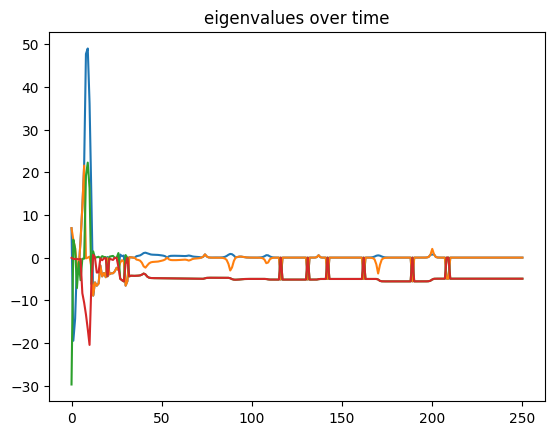

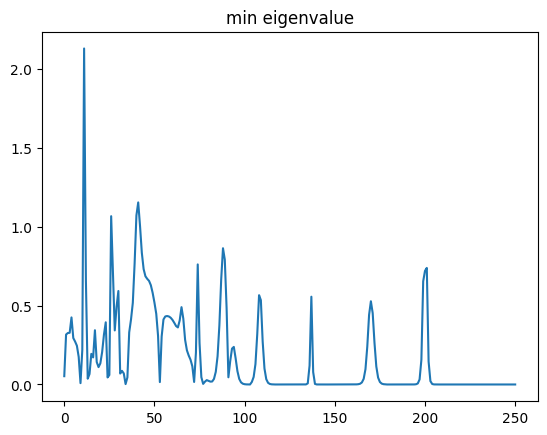

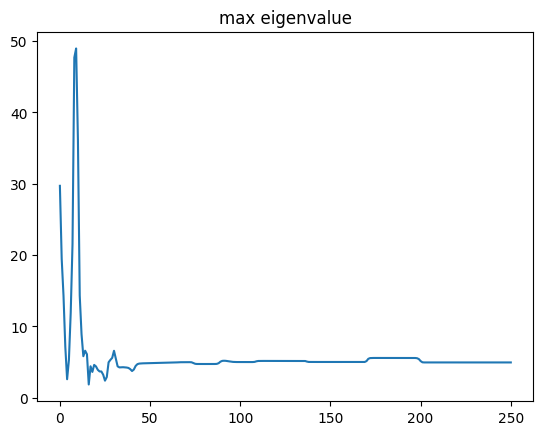

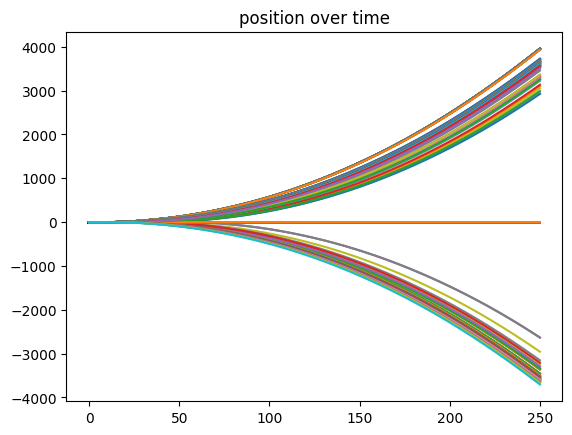

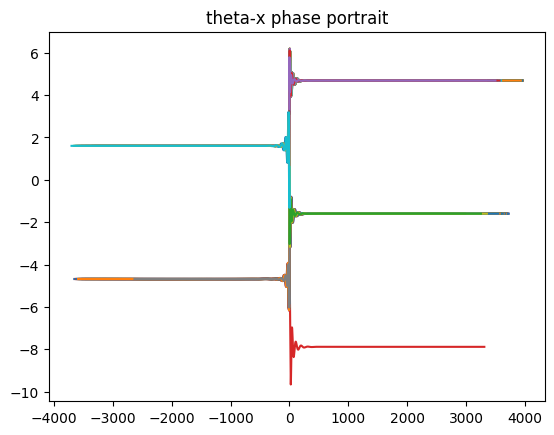

100%|██████████| 250/250 [00:00<00:00, 692.36it/s]


torch.Size([1000, 251, 4])


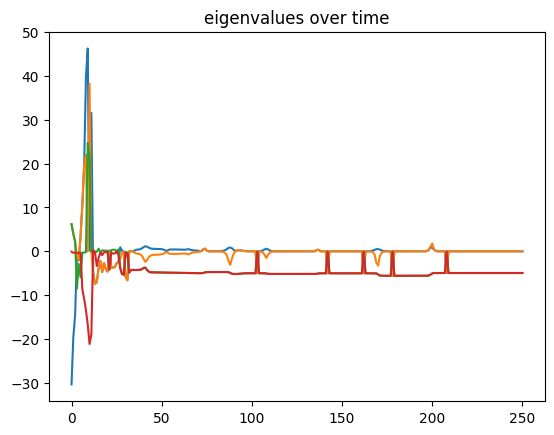

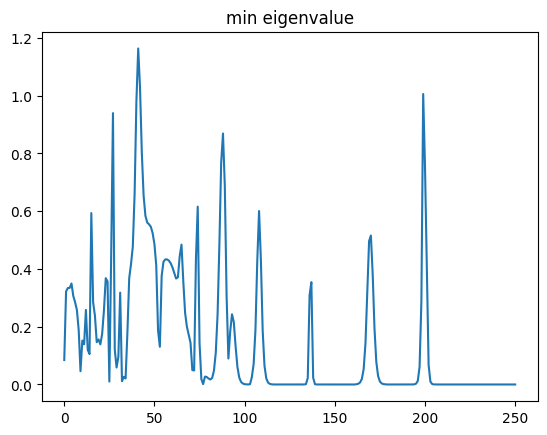

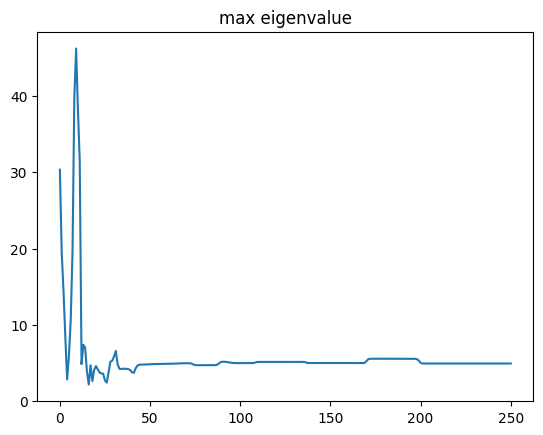

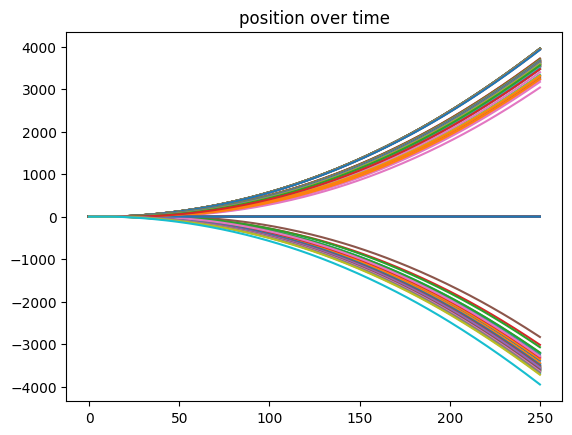

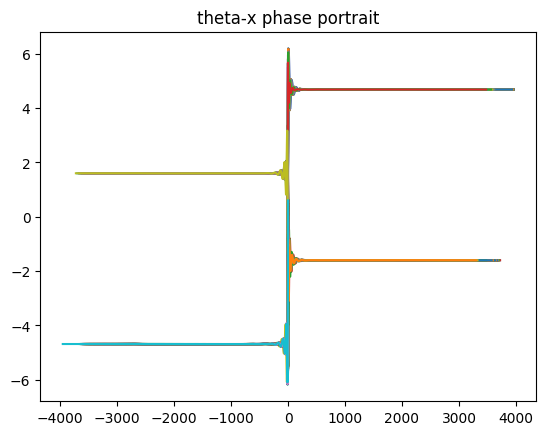

100%|██████████| 250/250 [00:00<00:00, 690.29it/s]


torch.Size([1000, 251, 4])


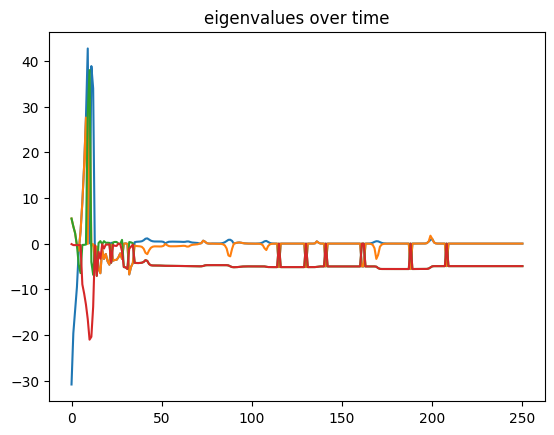

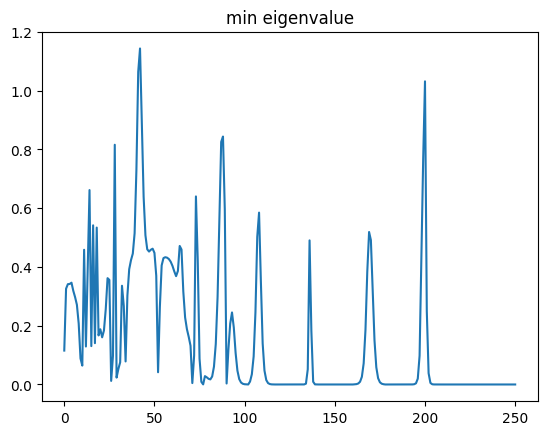

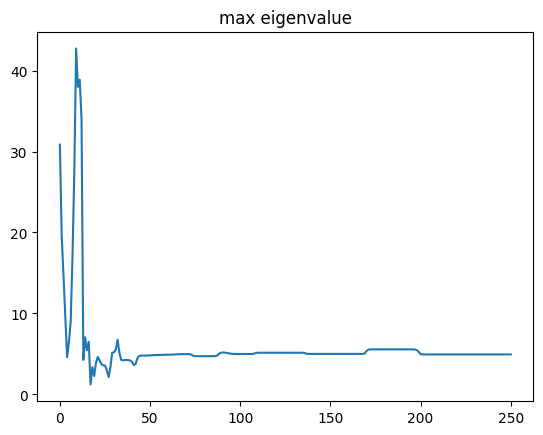

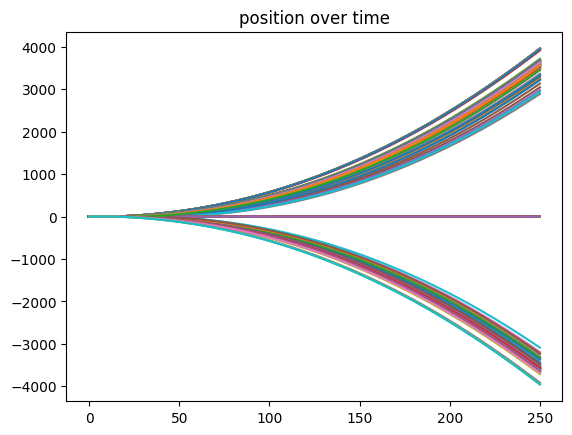

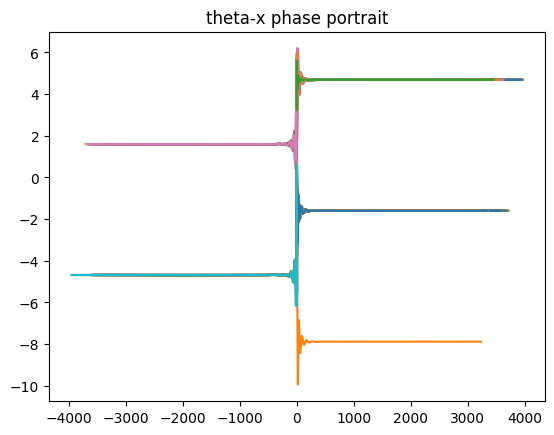

100%|██████████| 250/250 [00:00<00:00, 322.88it/s]


torch.Size([1000, 251, 4])


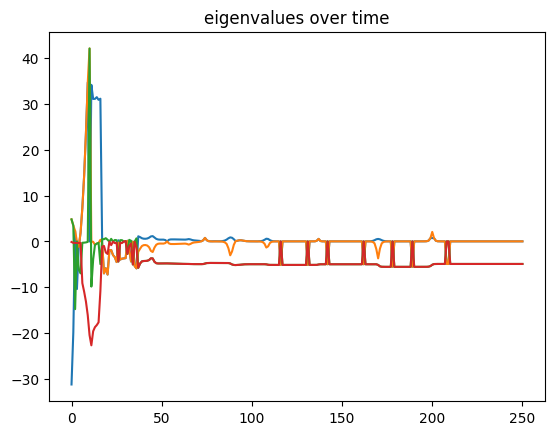

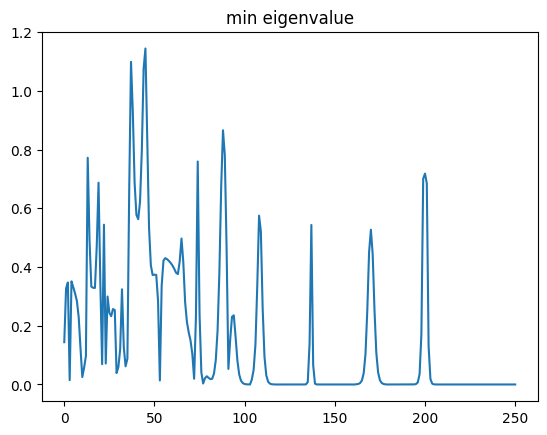

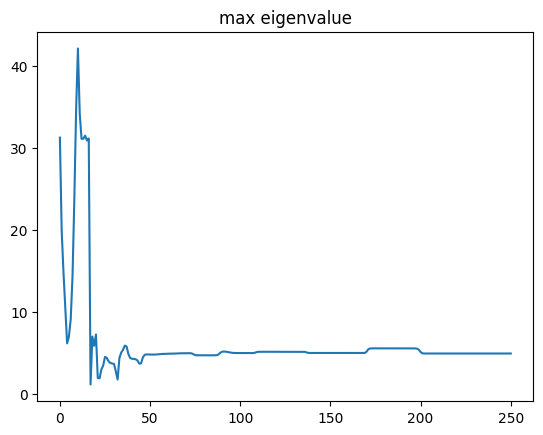

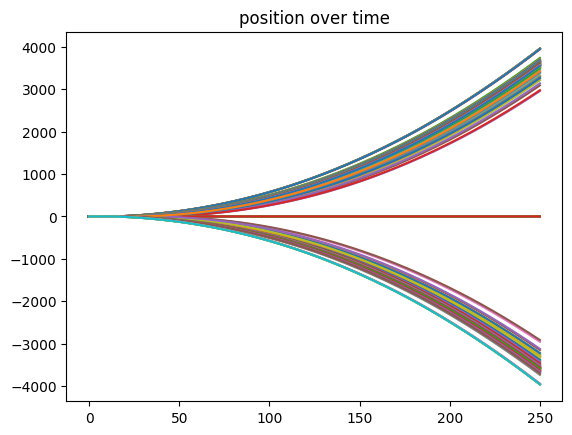

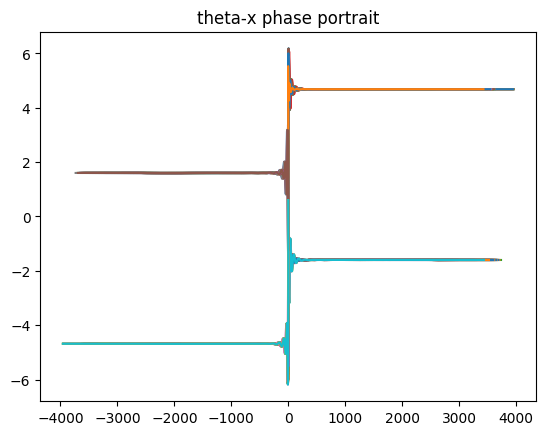

100%|██████████| 250/250 [00:00<00:00, 693.71it/s]


torch.Size([1000, 251, 4])


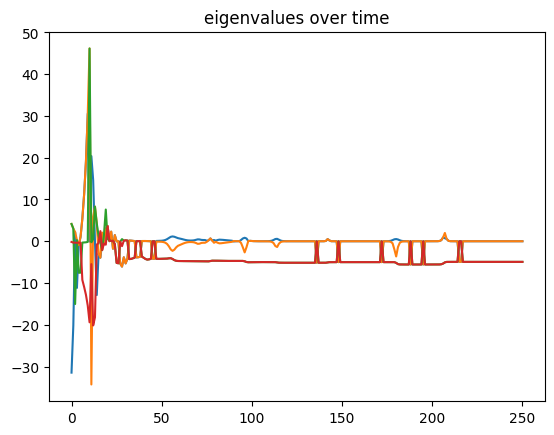

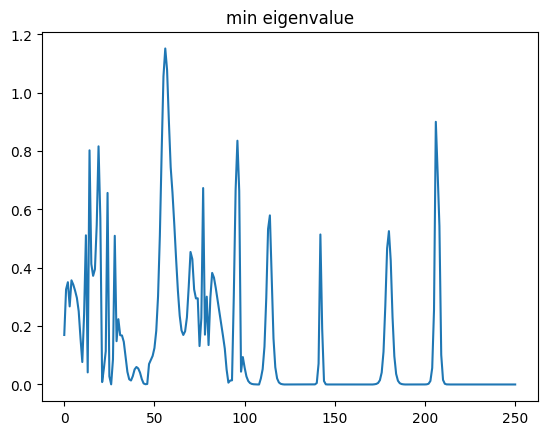

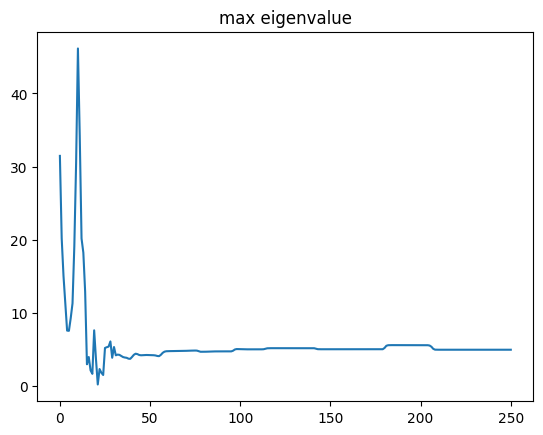

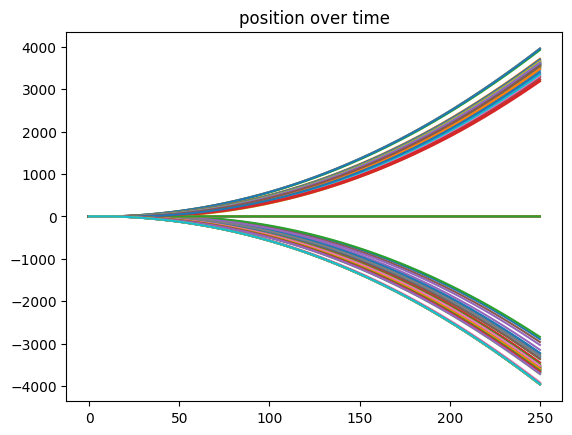

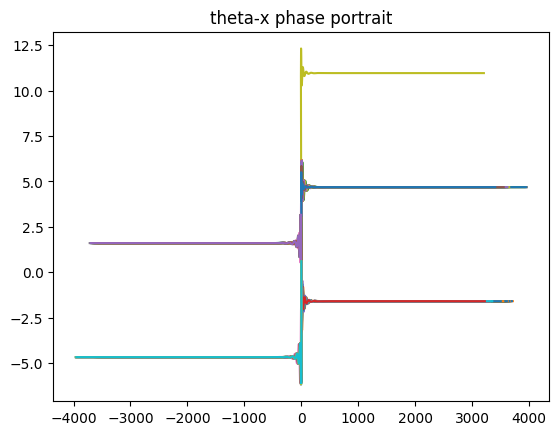

100%|██████████| 250/250 [00:00<00:00, 692.87it/s]


torch.Size([1000, 251, 4])


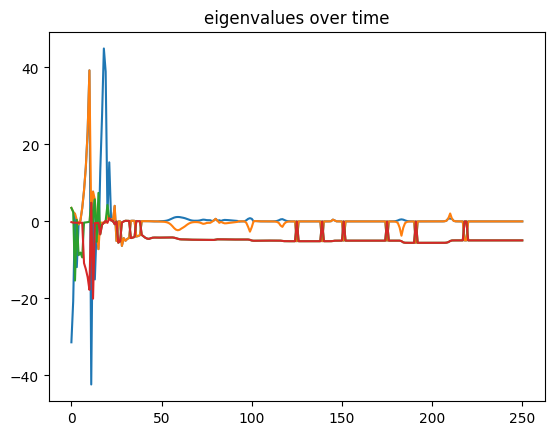

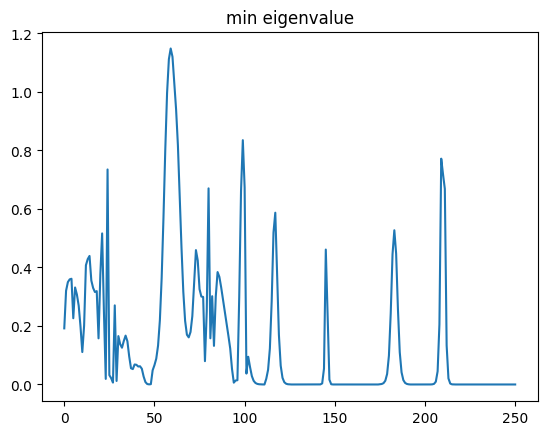

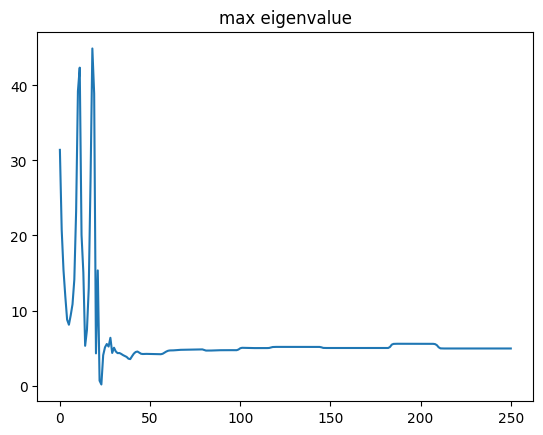

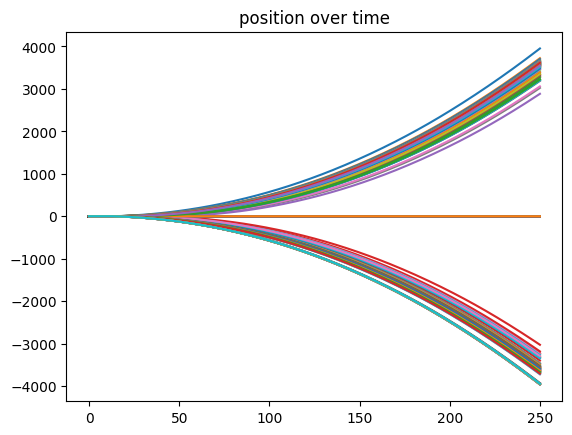

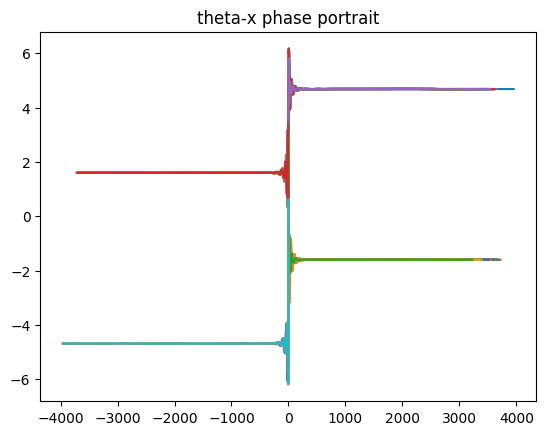

In [27]:
from theorem_tools import plot_eigenvalues
plot_eigenvalues(ae, fdyn, lqr, roa=[1.0, 0.5, 0.6, 0.5], roa_per_axis=[10, 10, 10, 10], n_chunks=6, T_roa=250)